In [1]:
import numpy as np
import pandas as pd
import os
from multiprocessing import Pool
import warnings
warnings.filterwarnings("ignore")
import random
from functools import partial
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import itertools
import math
os.chdir('/home/bhanselman/gbt_mias/ronit')
from spectra import *

In [2]:
cleaned_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/cleaned_g/'
spectra = os.listdir(cleaned_dir)

# Old normalize code

In [ ]:
spectrum = Spectrum(cleaned_dir + spectra[0], interpret=False)

In [ ]:
def static_normalize(self, window=111, fast=False):
        from scipy.optimize import curve_fit

        c = 2.9979e5
        is_decay = True
        v_virial = 225

        freq_diff = self.freq[1] - self.freq[0]
        ind_xs = np.arange(-(window//2), window//2+1)
        lower = (window - 1) // 2
        upper = (window + 1) // 2
        ys_mean = self.power / self.power.mean()

        def fit_func(x, A, b,c, d, f, g, h, center):
            ''' Weighted polynomial plus Gaussian
            '''
            y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2)) + b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5
            return y
            
        def fit_func2(x, b,c, d, f, g, h):
            ''' polynomial
            '''
            y = b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5
            return y
        
        normalized_spectrum = []
        # chi_squareds = []
        excluded_count = 0

        func1_guess = [2, 1,1,1,1,1,1, 0]
        func2_guess = [1,1,1,1,1,1]

        
        if not fast:
            for idx, i in enumerate(range(lower, len(self.freq)-upper)):
                
                current_ys = ys_mean[i-lower:i+upper]
                idx_finite = np.isfinite(current_ys)

                if any(current_ys < 0.0001):
                    normalized_spectrum.append(1)
                    excluded_count += 1
                    continue

                if is_decay:
                    sigma = v_virial*self.freq[i]/(c*np.sqrt(3))
                else:
                    sigma = v_virial*self.freq[i]/(c*np.sqrt(6))

                # Fit the defined function to the data using curve fitting

                #polynomial + gaussian
                parameters, covariance = curve_fit(fit_func, ind_xs[idx_finite], current_ys[idx_finite],  p0=func1_guess, maxfev=1000000)
                parameters    
                #polynomial + guassian
                fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_= parameters

                cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
                xs_1 = ind_xs[idx_finite][:np.argmin(np.abs(ind_xs[idx_finite] - (cent-12)))]
                xs_2 = ind_xs[idx_finite][np.argmin(np.abs(ind_xs[idx_finite] - (cent+12))):]
                ys_1 = current_ys[idx_finite][:np.argmin(np.abs(ind_xs[idx_finite] - (cent-12)))]
                ys_2 = current_ys[idx_finite][np.argmin(np.abs(ind_xs[idx_finite] - (cent+12))):]
                #polynomial
                parameters2, covariance = curve_fit(fit_func2, np.concatenate((xs_1, xs_2)), np.concatenate((ys_1, ys_2)),  p0=func2_guess, maxfev=1000000)
                #polynomial
                fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2      

                p = fit_func2(0, fit_b,fit_c, fit_d, fit_f, fit_g, fit_h)
                pg = fit_func(0, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
                fit_ys = fit_func(ind_xs, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
                chi_squared = np.sum((current_ys[idx_finite] - fit_ys[idx_finite])**2/fit_ys[idx_finite])
                # chi_squareds.append(chi_squared)

                if np.isfinite(chi_squared) and chi_squared > 0:
                    normalized_spectrum.append(pg/p)
                else:
                    normalized_spectrum.append(1)
                    excluded_count += 1


        self.freq = self.freq[lower: len(self.freq)-upper]
        self.power = np.array(normalized_spectrum)
        self.label = f"{self.label}_static_normalized_{window}"

In [ ]:
def adaptive_normalization(self, position=1, window=111):
    """Smart normalization with 10ms timeouts"""
    c = 2.9979e5
    is_decay = True
    v_virial = 225

    freq_diff = self.freq[1] - self.freq[0]
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = self.power / self.power.mean()

    def fit_func(x, A, b, c, d, f, g, h, center):
        return (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2)) + b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5

    def fit_func2(x, b, c, d, f, g, h):
        return b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5

    class TimeoutException(Exception):
        pass

    def handler(signum, frame):
        raise TimeoutException()

    normalized_spectrum = []
    excluded_count = 0

    # Configure tqdm with position parameter for multiprocessing
    tqdm_kwargs = {
        'desc': f"Normalizing {self.label[:20]}...", 
        'leave': True,
        'mininterval': 0.5
    }
    if position is not None:
        tqdm_kwargs['position'] = position

    for idx, i in enumerate(range(lower, len(self.freq)-upper)):

        current_ys = ys_mean[i-lower:i+upper]
        idx_finite = np.isfinite(current_ys)

        if is_decay:
            sigma = v_virial*self.freq[i]/(c*np.sqrt(3))
        else:
            sigma = v_virial*self.freq[i]/(c*np.sqrt(6))

        # Smart initial guesses
        data_mean = np.mean(current_ys[idx_finite])
        data_std = np.std(current_ys[idx_finite])
        func1_guess = [data_std/5, data_mean, data_std/10, 0, 0, 0, 0, 0]
        func2_guess = [data_mean, data_std/10, 0, 0, 0, 0]

        try:
            # Setup 10ms timeout
            if hasattr(signal, "SIGALRM"):
                signal.signal(signal.SIGALRM, handler)
                signal.setitimer(signal.ITIMER_REAL, 0.01)

            parameters = curve_fit(fit_func, ind_xs[idx_finite], current_ys[idx_finite], 
                                p0=func1_guess, maxfev=50000)[0]

            fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_ = parameters

            # Exclude Gaussian region for polynomial-only fit
            cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
            exclusion_range = 12
            mask1 = ind_xs[idx_finite] < (cent - exclusion_range)
            mask2 = ind_xs[idx_finite] > (cent + exclusion_range)
            combined_mask = mask1 | mask2

            if np.sum(combined_mask) > 6:
                parameters2 = curve_fit(fit_func2, ind_xs[idx_finite][combined_mask], 
                                      current_ys[idx_finite][combined_mask],
                                      p0=func2_guess, maxfev=50000)[0]
                fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2
            else:
                fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = func2_guess

            p = fit_func2(0, fit_b, fit_c, fit_d, fit_f, fit_g, fit_h)
            pg = fit_func(0, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)

            result = pg/p if np.isfinite(pg/p) else 1.0
            normalized_spectrum.append(result)

        except (TimeoutException, RuntimeError, ValueError):
            normalized_spectrum.append(1.0)
            excluded_count += 1
        finally:
            if hasattr(signal, "SIGALRM"):
                signal.setitimer(signal.ITIMER_REAL, 0)

    self.freq = self.freq[lower: len(self.freq)-upper]
    self.power = np.array(normalized_spectrum)
    self.label = f"{self.label}_adaptive_normalized"

In [ ]:
spectrum.plot()

In [ ]:
adaptive_normalization(spectrum)
spectrum.plot()

In [ ]:
spectrum.plot(xlim=(9000,9100))

## A simple metric: std of the spectrum

In [ ]:
import itertools
#params = list(itertools.product(np.arange(55, 205, 10), np.arange(1, 6)))
params = np.arange(55, 205, 10)
params

In [ ]:
import gc

def norm_std(window):
    spectrum = Spectrum(cleaned_dir + spectra[0], interpret=False)
    static_normalize(spectrum, window=window)
    std = np.std(spectrum.power)
    del spectrum
    gc.collect()
    return std

with Pool(maxtasksperchild=10) as p:
    stds = list(tqdm(p.imap_unordered(norm_std, params), total=len(params)))
    
plt.plot(params, stds)

# Signal injection

## One signal size

In [12]:
from tqdm.notebook import tqdm
filepath_to_inject = cleaned_dir
#info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/all_xband_info.csv' #'/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv'
c = 299792
v_virial = 250 # km/s
v_earth  = 225 # km/s
dm_profile = 'nfw'

In [3]:
def inject(xs, ys, theta, sig_loc, signal_size, v_earth, v_virial, is_decay, name, targ_info, sig_amp, sig_std):
    shift_factor = get_shift_factor(theta, v_earth)
    sig_loc, sig_std, sig_amp = sig_loc*shift_factor, sig_std*shift_factor, sig_amp / shift_factor
    return (ys + sig_amp*np.exp(-(xs - sig_loc)**2 / (2*sig_std**2)))
    
def get_shift_factor(theta, v_earth):
    beta = v_earth / c
    radians_from_v_earth = np.radians(theta)
    return 1 + beta*np.cos(radians_from_v_earth)

def inject_spaced(signal_size, loc, spacing, filepath_to_save, template=False, is_decay=True):
    os.makedirs(filepath_to_save, exist_ok=True)
    def get_vals(sig_loc):
        if is_decay:
            sig_std = v_virial*sig_loc/(c*np.sqrt(3))
            sig_amp_ratio = 2.75e23*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile
            return (sig_std, sig_amp_ratio, col_name)
        else:
            sig_std = v_virial*sig_loc/(c*np.sqrt(6))
            sig_amp_ratio = 3.55e28*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile+'_sq'
            return (sig_std, sig_amp_ratio, col_name)
    targ_info = pd.read_csv(info_dir).set_index('source')
    names = os.listdir(filepath_to_inject)

    for name in tqdm(names):
        try:
            file = np.load(os.path.join(filepath_to_inject, name))
            spec =  file[1]
            freq = file[0]
            if template:
                spec = np.ones_like(spec)
            spec_med = np.median(spec)
            theta = targ_info.loc[name[:-4], 'theta']

            loc_loop = loc
            end = freq[freq.size-20]
            # salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
            while loc_loop <= end:
                sig_std, sig_amp_ratio, col_name = get_vals(loc_loop)
                amp_ratio = sig_amp_ratio*targ_info.loc[name[:-4], col_name]
                amp = spec_med*amp_ratio
                salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
                spec = salted
                loc_loop = loc_loop + spacing
            save_loc = os.path.join(filepath_to_save, name)
            np.save(save_loc, np.array([freq, spec]))
        except Exception as e:
            print(e)  

In [8]:
filepath_to_inject = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/0/preprocessed/'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/0/injected_28/'
#'/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/injected_snr'

In [36]:
len(os.listdir(injected_dir))

4918

In [34]:
inject_spaced(1e-28, 7520, 100, injected_dir)

  0%|          | 0/4918 [00:00<?, ?it/s]

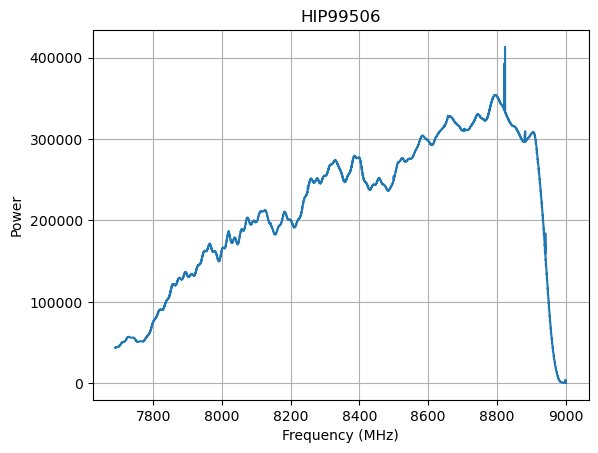

In [11]:
import random
path = os.path.join(injected_dir, random.choice(os.listdir(injected_dir)))
test = Spectrum(path, interpret=False)
test.plot()#xlim=(8495,8545))

In [12]:
freq_diff = test.freq[1] - test.freq[0]
freq_diff

0.18310546875

In [13]:
v_virial / (c*np.sqrt(3)) / freq_diff * 4

0.010517633126081671

### Normalization >:)

In [4]:
normalized_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/normalized_injected_test/'
normalized_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/normalized_uninjected_test/'

# uninjected_dir = cleaned_dir
# injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/data/injected_test/'
# template_dir = '/home/dataadmin/GBTData/SharedDataDirectory/data/template_test/'
# normalized_injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/data/normalized_injected_test/'
# normalized_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/data/normalized_uninjected_test/'
# normalized_template_dir = '/home/dataadmin/GBTData/SharedDataDirectory/data/normalized_template_test/'

# Better normalization? (Aya's code)
def normalize(data, data_dir=None, save_dir=None, window=111, freq=None, width=200, nsigma=2, order=5, is_decay=True):
    if data_dir:
        xs, ys = np.load(os.path.join(data_dir, data))
    else:
        xs, ys = data
    freq_diff = xs[1] - xs[0]
    if freq:
        #index = int((freq - xs[0]) / freq_diff)
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
        offset = 16 - (index-width) % 16
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = ys / ys.mean()
    for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma
    
    def fit_func(x, A, center, *coeffs, window_center=0):
        ''' Weighted polynomial plus Gaussian
        '''
        sigma = get_sigma(window_center + center)
        y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2))
        y += fit_func2(x, *coeffs)
        return y
        
    def fit_func2(x, *coeffs): #polynomial
        ''' 
        '''
        y = 0
        for i, coeff in enumerate(coeffs):
            y += coeff * x ** i
        return y

    normalized_spectrum = []
    # Center bounds
    lower_bound = -(window//2) * freq_diff
    upper_bound = (window//2+1) * freq_diff
    #print(-(window//2), (window//2+1))
    guesses = np.ones_like(range(order+1)).tolist()
    bounds = (
        (0, lower_bound, *[-np.inf for _ in guesses]),
        (np.inf, upper_bound, *[np.inf for _ in guesses])
    )
    
    #print(f'n:{len(xs)-lower-upper}')
    # Loop through the data points and divide each point by the polynomial 
    for i in range(lower, len(xs)-upper):
        
        #print(f'{i}/{len(xs)-upper-lower}')
        current_ys = ys_mean[i-lower:i+upper]
        idx = np.isfinite(current_ys)

        # Fit the defined function to the data using curve fitting
        fit_func_wrapper = partial(fit_func, window_center = xs[i])
        #polynomial + gaussian
        parameters, covariance = curve_fit(
            fit_func_wrapper,
            ind_xs[idx],
            current_ys[idx],
            p0=[2, 1, *guesses],
            bounds=bounds,
            maxfev=1000000)
        #polynomial + guassian
        # fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_= parameters

        # cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        fit_center_ = parameters[1]
        cent = fit_center_/freq_diff
        sig = nsigma * get_sigma(xs[i] + fit_center_)/freq_diff # 3 sigma 
        # xs_1 = ind_xs[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # xs_2 = ind_xs[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        # ys_1 = current_ys[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # ys_2 = current_ys[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        #sig = 12 # testing the old range
        mask1 = ind_xs[idx] < (cent - sig)
        mask2 = ind_xs[idx] > (cent + sig)
        combined_mask = mask1 | mask2
        xs_masked = ind_xs[idx][combined_mask]
        ys_masked = current_ys[idx][combined_mask]
        #print(f'Center (bins): {cent}, 3-sigma (bins): {sig}, xs: {xs_masked}')
        
        #polynomial
        # parameters2, covariance = curve_fit(fit_func2, np.concatenate((xs_1, xs_2)), np.concatenate((ys_1, ys_2)),  p0=[1,1,1,1,1,0], maxfev=1000000)
        parameters2, covariance = curve_fit(fit_func2, xs_masked, ys_masked, p0=guesses, maxfev=1000000)
        #polynomial
        # fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2      
        
        p = fit_func2(0, *parameters2)
        pg = fit_func_wrapper(0, *parameters)
        #fit_ys = fit_func(ind_xs, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
        # chi_squared = np.sum((current_ys[idx] - fit_ys[idx])**2/fit_ys[idx])
        # chi_squareds.append(chi_squared)
        normalized_spectrum.append(pg/p)
    
    new_xs = xs[lower: len(xs)-upper]
    normalized = np.array([new_xs, normalized_spectrum])
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        np.save(os.path.join(save_dir, data), normalized)
    return normalized

In [ ]:
import warnings
warnings.filterwarnings("ignore")

normalized_func = partial(
    normalize_weighted,
    data_dir=cleaned_dir,
    save_dir=normalized_uninjected_dir,
    window=161,
    freq=8520,
    width=70,
    nsigma=1.6,
    order=5)

spectra_to_normalize = os.listdir(cleaned_dir) #injected_dir
with Pool() as p:
    result = list(tqdm(p.imap_unordered(normalized_func, spectra_to_normalize), total=len(spectra_to_normalize)))

In [56]:
ans = v_virial*11000/(c*np.sqrt(3)) / freq_diff * 3 * 2
ans

173.54094658034757

In [57]:
ans*1.5

260.3114198705214

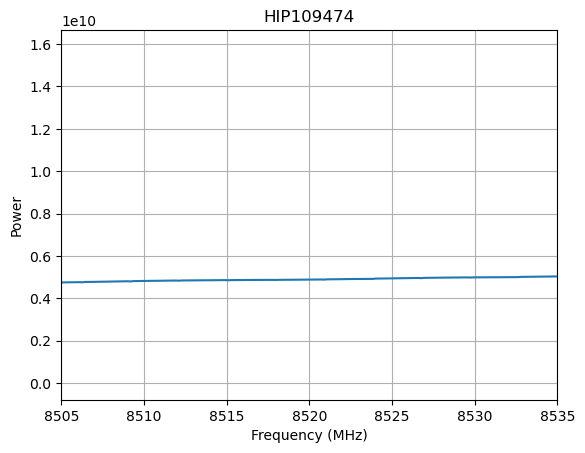

In [48]:
wtf = Spectrum(cleaned_dir + spectra_to_normalize[0], interpret=False)
wtf.plot(xlim=(8505,8535))

### Weighted polynomial

In [1]:
def normalize_weighted(data, data_dir=None, save_dir=None, a=0.1, b=1, window=261, freq=None, width=200, order=5, is_decay=True):#xs, ys, a, b, sigma, order, window, rb_size=1):
    """
    Standard rolling polynomial normalize procedure. Updated.
    """
    if data_dir:
        xs, ys = np.load(os.path.join(data_dir, data))
    else:
        xs, ys = data
    freq_diff = xs[1] - xs[0]
    offset = 0
    if freq:
        #index = int((freq - xs[0]) / freq_diff)
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
        offset = 16 - (index-width) % 16
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = ys / ys.mean()
    for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma

    normalized_spectrum = []

    # Loop through the data points and divide each point by the polynomial 
    for i in range(lower, len(xs)-upper):

        current_ys = ys_mean[i-lower:i+upper]
        idx = np.isfinite(current_ys)

        # Unweighted fit
        unweighted_params = np.polyfit(ind_xs[idx], current_ys[idx], order)
        
        # Weighted fit
        sigma = get_sigma(xs[i])
        weights = 1 - a*np.exp(-(freq_diff*ind_xs[idx])**2 / (2*b*sigma**2))
        weighted_params = np.polyfit(ind_xs[idx], current_ys[idx], order, w=weights)
        
        unweighted = np.poly1d(unweighted_params)(0)
        weighted = np.poly1d(weighted_params)(0)
        
        normalized_spectrum.append(unweighted/weighted)
    
    new_xs = xs[lower: len(xs)-upper]
    #new_ys = ys_mean[lower: len(xs)-upper]
    normalized = np.array([new_xs, normalized_spectrum])
    #old = np.array([new_xs, new_ys])
    if save_dir:
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        np.save(os.path.join(save_dir, data), normalized)
    return normalized

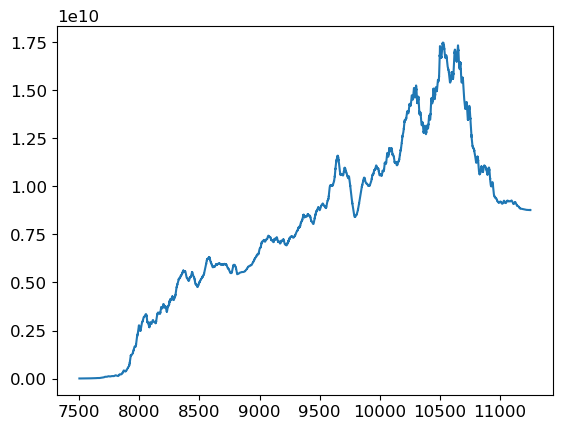

In [192]:
test = np.load(os.path.join(cleaned_dir, os.listdir(injected_dir)[3]))
plt.plot(test[0], test[1])

In [195]:
a=0.1
test_norm = normalize_weighted(test, a=a, freq=8520, width=70, window=161)
test_norm

array([[8.46469116e+03, 8.46487427e+03, 8.46505737e+03, ...,
        8.57455444e+03, 8.57473755e+03, 8.57492065e+03],
       [9.99875070e-01, 9.99872598e-01, 9.99875457e-01, ...,
        9.99928098e-01, 9.99929553e-01, 9.99931093e-01]])

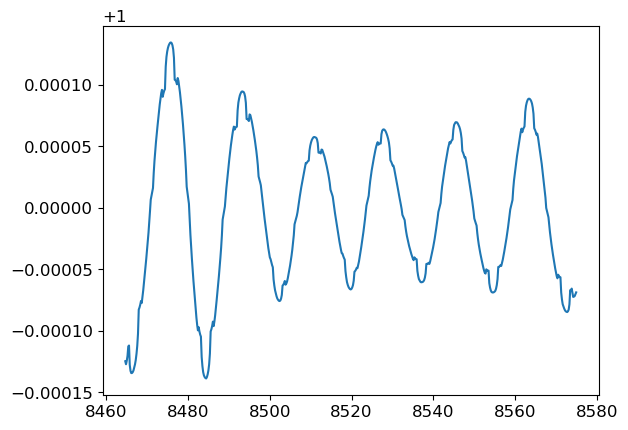

In [196]:
plt.plot(test_norm[0], test_norm[1])
plt.savefig(f'/home/bhanselman/a_{a}.png')

In [16]:
def inject_spaced_one(name, data_dir=None, save_dir=None, signal_size=1e-27, loc=7520, spacing=100, template=False, is_decay=True):
    freq, spec = np.load(os.path.join(data_dir, name))
    
    if loc == 'start':
        loc = freq[0] + 20
    
    def get_vals(sig_loc):
        if is_decay:
            sig_std = v_virial*sig_loc/(c*np.sqrt(3))
            sig_amp_ratio = 2.75e23*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile
            return (sig_std, sig_amp_ratio, col_name)
        else:
            sig_std = v_virial*sig_loc/(c*np.sqrt(6))
            sig_amp_ratio = 3.55e28*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile+'_sq'
            return (sig_std, sig_amp_ratio, col_name)
    targ_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/all_xband_info.csv').set_index('source')

    if template:
        spec = np.ones_like(spec)
    spec_med = np.median(spec)
    theta = targ_info.loc[name[:-4], 'theta']

    loc_loop = loc
    end = freq[freq.size-20]
    # salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
    while loc_loop <= end:
        sig_std, sig_amp_ratio, col_name = get_vals(loc_loop)
        amp_ratio = sig_amp_ratio*targ_info.loc[name[:-4], col_name]
        amp = spec_med*amp_ratio
        salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
        spec = salted
        loc_loop = loc_loop + spacing
    injected = np.array([freq, spec])
    if save_dir:
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        np.save(os.path.join(save_dir, name), injected)
    return injected

In [10]:
# Moving spliced banks into preprocessed folders
import shutil
spliced_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/'
banks = ['0', '1', '2', '3']
for bank in banks:
    path = os.path.join(spliced_dir, bank)
    if not os.path.exists(os.path.join(path, 'preprocessed')):
        os.makedirs(os.path.join(path, 'preprocessed'))
    for file in os.listdir(path):
        if file.endswith('.npy'):
            shutil.move(os.path.join(path, file), os.path.join(path, 'preprocessed', file))

In [ ]:
with Pool() as p:
    banks = ['0', '1', '2', '3']
    for bank in banks:
        cleaned_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/{bank}/preprocessed'
        spectra = os.listdir(cleaned_dir) #injected_dir
        
        injected_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/{bank}/injected'
        normalized_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/{bank}/normalized_weighted'
        
        inject_func = partial(
            inject_spaced_one,
            data_dir=cleaned_dir,
            save_dir=injected_dir,
            signal_size=1e-27,
            loc='start',
            spacing=100,
        )
        
        normalize_func = partial(
            normalize_weighted,
            data_dir=injected_dir,
            save_dir=normalized_dir,
            window=161,
            # freq=8520,
            # width=70,
            order=5
        )

        print(f'Injecting and normalizing bank {bank}')

        injected = list(tqdm(p.imap_unordered(inject_func, spectra), total=len(spectra)))
        normalized = list(tqdm(p.imap_unordered(normalize_func, spectra), total=len(spectra)))

Injecting and normalizing bank 0


  0%|          | 0/4918 [00:00<?, ?it/s]

  0%|          | 0/4918 [00:00<?, ?it/s]

### Dynamic

In [5]:
def normalize_dynamic(data, data_dir=None, save_dir=None, window_factor=0.02, freq=None, width=200, nsigma=2, order=5, is_decay=True):
    if data_dir:
        xs, ys = np.load(os.path.join(data_dir, data))
    else:
        xs, ys = data
    freq_diff = xs[1] - xs[0]
    offset = 0
    if freq:
        #index = int((freq - xs[0]) / freq_diff)
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
        offset = 16 - (index-width) % 16

    ys_mean = ys / ys.mean()
    for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma
    
    def fit_func(x, A, center, *coeffs, window_center=0):
        ''' Weighted polynomial plus Gaussian
        '''
        sigma = get_sigma(window_center + center)
        y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2))
        y += fit_func2(x, *coeffs)
        return y
        
    def fit_func2(x, *coeffs): #polynomial
        ''' 
        '''
        y = 0
        for i, coeff in enumerate(coeffs):
            y += coeff * x ** i
        return y
    
    new_xs = []
    normalized_spectrum = []
    
    def round_up_to_nearest_odd(number):
        ceiled_number = math.ceil(number)
        return int(ceiled_number + 1) if ceiled_number % 2 == 0 else int(ceiled_number)
    
    # Loop through the data points and divide each point by the polynomial 
    for i, x in enumerate(xs):
        window = round_up_to_nearest_odd(window_factor * x)
        if i < (window//2):
            continue
        if i > len(xs) - (window//2 + 1):
            break
        ind_xs = np.arange(-(window//2), window//2+1)
        #print(f'{i}/{len(xs)-upper-lower}')
        current_ys = ys_mean[i-window//2:i+window//2+1]
        idx = np.isfinite(current_ys)
        
        # Center bounds
        lower_bound = -(window//2) * freq_diff
        upper_bound = (window//2) * freq_diff
        guesses = np.ones_like(range(order+1)).tolist()
        bounds = (
            (0, lower_bound, *[-np.inf for _ in guesses]),
            (np.inf, upper_bound, *[np.inf for _ in guesses])
        )
        
        # Fit the defined function to the data using curve fitting
        fit_func_wrapper = partial(fit_func, window_center = x)
        #polynomial + gaussian
        parameters, covariance = curve_fit(
            fit_func_wrapper,
            ind_xs[idx],
            current_ys[idx],
            p0=[2, 1, *guesses],
            bounds=bounds,
            maxfev=1000000)
        #polynomial + guassian
        # fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_= parameters

        # cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        fit_center_ = parameters[1]
        cent = fit_center_/freq_diff
        sig = nsigma * get_sigma(x + fit_center_)/freq_diff # 3 sigma 
        # xs_1 = ind_xs[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # xs_2 = ind_xs[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        # ys_1 = current_ys[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # ys_2 = current_ys[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        #sig = 12 # testing the old range
        mask1 = ind_xs[idx] < (cent - sig)
        mask2 = ind_xs[idx] > (cent + sig)
        combined_mask = mask1 | mask2
        xs_masked = ind_xs[idx][combined_mask]
        ys_masked = current_ys[idx][combined_mask]
        #print(f'Center (bins): {cent}, 3-sigma (bins): {sig}, xs: {xs_masked}')
        
        #polynomial
        # parameters2, covariance = curve_fit(fit_func2, np.concatenate((xs_1, xs_2)), np.concatenate((ys_1, ys_2)),  p0=[1,1,1,1,1,0], maxfev=1000000)
        parameters2, covariance = curve_fit(fit_func2, xs_masked, ys_masked, p0=guesses, maxfev=1000000)
        #polynomial
        # fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2      
        
        p = fit_func2(0, *parameters2)
        pg = fit_func_wrapper(0, *parameters)
        #fit_ys = fit_func(ind_xs, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
        # chi_squared = np.sum((current_ys[idx] - fit_ys[idx])**2/fit_ys[idx])
        # chi_squareds.append(chi_squared)
        new_xs.append(x)
        normalized_spectrum.append(pg/p)
    
    normalized = np.array([new_xs, normalized_spectrum])
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        np.save(os.path.join(save_dir, data), normalized)
    return normalized

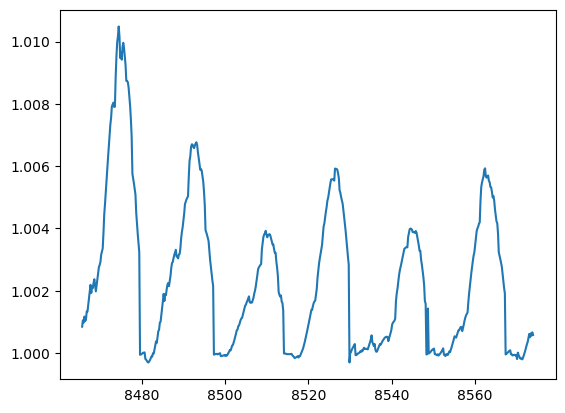

In [21]:
test = np.load(os.path.join(injected_dir, os.listdir(injected_dir)[3]))
test_norm_dynamic = normalize_dynamic(test, nsigma=1.5, freq=8520, width=70, window_factor=0.02)
plt.plot(*test_norm_dynamic)

In [20]:
0.02 * 8520

170.4

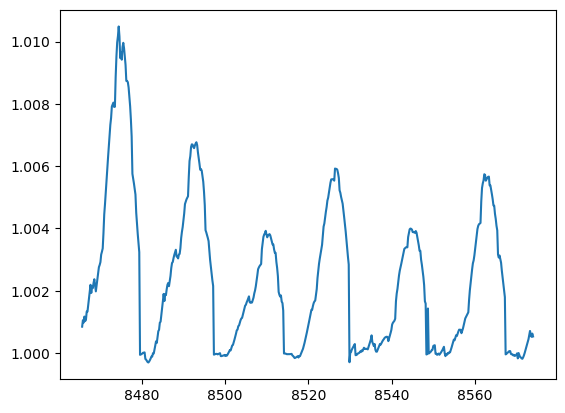

In [25]:
test_norm = normalize(test, nsigma=1.5, freq=8520, width=70, window=171)
plt.plot(*test_norm)

#### Comparison at nsigma = 1.9476, factor = 0.035

In [6]:
test_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_bayes_27_dynamic_new_freqs_pg_savgol_sigfilt_bounded/0/injected/'
name = random.choice(os.listdir(test_dir))

In [8]:
inj_path = os.path.join(test_dir, name)

In [9]:
np.load(inj_path)

array([[7689.057827  , 7689.24093246, 7689.42403793, ..., 9001.00851059,
        9001.19161606, 9001.37472153],
       [3554.4541665 , 3522.23239378, 3516.50397432, ...,  473.00744305,
         476.54317527,  494.31246321]])

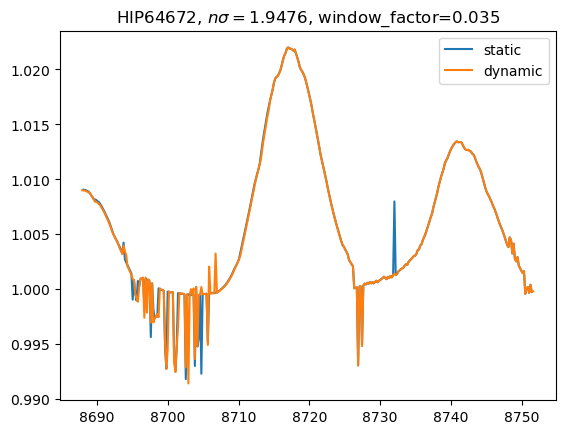

In [15]:
def round_up_to_nearest_odd(number):
    ceiled_number = math.ceil(number)
    return int(ceiled_number + 1) if ceiled_number % 2 == 0 else int(ceiled_number)
window = round_up_to_nearest_odd(0.035*8720)
static_norm = normalize(np.load(inj_path), freq=8720, width=60, nsigma=1.9476, window=window)
dynamic_norm = normalize_dynamic(np.load(inj_path), freq=8720, width=60, nsigma=1.9476, window_factor=0.035)
plt.plot(*static_norm, label='static')
plt.plot(*dynamic_norm, label='dynamic')
plt.title(f'{name[:-4]}, $n\sigma = 1.9476$, window_factor=0.035')
plt.legend()

### Heatmaps

In [3]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv')
info

,source,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP31319,186.351085,8.695369,96.277791,169.246613,9.989327e+07,4.985144e+14,2.521213e+08,1.142265e+15,8.550127e+07,4.070035e+14,2.178480e+07,2.878614e+13
1,HIP32010,190.341431,8.572469,100.224648,166.597332,1.002477e+08,5.013753e+14,2.526114e+08,1.146475e+15,8.582101e+07,4.093366e+14,2.186996e+07,2.896046e+13
2,HIP109474,110.001367,11.409925,22.910600,109.589732,1.317070e+08,7.926500e+14,2.910501e+08,1.506253e+15,1.140915e+08,6.436282e+14,2.958756e+07,4.714941e+13
3,HIP108917,106.158302,7.365894,17.717209,106.021354,1.357860e+08,8.360996e+14,2.953828e+08,1.550574e+15,1.177252e+08,6.779158e+14,3.061020e+07,4.993177e+13
4,HIP108110,106.680210,9.628666,19.191186,106.438508,1.352906e+08,8.307496e+14,2.948637e+08,1.545222e+15,1.172845e+08,6.737044e+14,3.048574e+07,4.958828e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,HIP15887,149.806492,-10.597138,60.373468,148.167127,1.050097e+08,5.406830e+14,2.590606e+08,1.202746e+15,9.011593e+07,4.413427e+14,2.301803e+07,3.136458e+13
1920,HIP17060,153.540710,-10.981984,64.061744,151.504736,1.038346e+08,5.308310e+14,2.574921e+08,1.188912e+15,8.905625e+07,4.333300e+14,2.273404e+07,3.076043e+13
1921,HIP17042,153.751239,-11.330181,64.300575,151.570461,1.038130e+08,5.306502e+14,2.574630e+08,1.188657e+15,8.903670e+07,4.331829e+14,2.272880e+07,3.074936e+13
1922,HIP18912,159.467523,-10.845547,69.850349,156.889010,1.022395e+08,5.176167e+14,2.553390e+08,1.170077e+15,8.761752e+07,4.225729e+14,2.234923e+07,2.995176e+13


In [4]:
import math
info['cos_theta'] = [math.cos(math.radians(theta)) for theta in info['theta']]
info['cos_phi'] = [math.cos(math.radians(phi)) for phi in info['phi']]
info

,source,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq,cos_theta,cos_phi
0,HIP31319,186.351085,8.695369,96.277791,169.246613,9.989327e+07,4.985144e+14,2.521213e+08,1.142265e+15,8.550127e+07,4.070035e+14,2.178480e+07,2.878614e+13,-0.109349,-0.982439
1,HIP32010,190.341431,8.572469,100.224648,166.597332,1.002477e+08,5.013753e+14,2.526114e+08,1.146475e+15,8.582101e+07,4.093366e+14,2.186996e+07,2.896046e+13,-0.177508,-0.972765
2,HIP109474,110.001367,11.409925,22.910600,109.589732,1.317070e+08,7.926500e+14,2.910501e+08,1.506253e+15,1.140915e+08,6.436282e+14,2.958756e+07,4.714941e+13,0.921113,-0.335283
3,HIP108917,106.158302,7.365894,17.717209,106.021354,1.357860e+08,8.360996e+14,2.953828e+08,1.550574e+15,1.177252e+08,6.779158e+14,3.061020e+07,4.993177e+13,0.952570,-0.275996
4,HIP108110,106.680210,9.628666,19.191186,106.438508,1.352906e+08,8.307496e+14,2.948637e+08,1.545222e+15,1.172845e+08,6.737044e+14,3.048574e+07,4.958828e+13,0.944427,-0.282986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,HIP15887,149.806492,-10.597138,60.373468,148.167127,1.050097e+08,5.406830e+14,2.590606e+08,1.202746e+15,9.011593e+07,4.413427e+14,2.301803e+07,3.136458e+13,0.494344,-0.849590
1920,HIP17060,153.540710,-10.981984,64.061744,151.504736,1.038346e+08,5.308310e+14,2.574921e+08,1.188912e+15,8.905625e+07,4.333300e+14,2.273404e+07,3.076043e+13,0.437402,-0.878857
1921,HIP17042,153.751239,-11.330181,64.300575,151.570461,1.038130e+08,5.306502e+14,2.574630e+08,1.188657e+15,8.903670e+07,4.331829e+14,2.272880e+07,3.074936e+13,0.433650,-0.879403
1922,HIP18912,159.467523,-10.845547,69.850349,156.889010,1.022395e+08,5.176167e+14,2.553390e+08,1.170077e+15,8.761752e+07,4.225729e+14,2.234923e+07,2.995176e+13,0.344473,-0.919746


In [5]:
bins = np.linspace(-1, 1, 51)
info['cos_theta_bins'] = pd.cut(info['cos_theta'],  bins, labels=False)
info['cos_phi_bins'] = pd.cut(info['cos_phi'], bins, labels=False)
info

,source,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq,cos_theta,cos_phi,cos_theta_bins,cos_phi_bins
0,HIP31319,186.351085,8.695369,96.277791,169.246613,9.989327e+07,4.985144e+14,2.521213e+08,1.142265e+15,8.550127e+07,4.070035e+14,2.178480e+07,2.878614e+13,-0.109349,-0.982439,22,0
1,HIP32010,190.341431,8.572469,100.224648,166.597332,1.002477e+08,5.013753e+14,2.526114e+08,1.146475e+15,8.582101e+07,4.093366e+14,2.186996e+07,2.896046e+13,-0.177508,-0.972765,20,0
2,HIP109474,110.001367,11.409925,22.910600,109.589732,1.317070e+08,7.926500e+14,2.910501e+08,1.506253e+15,1.140915e+08,6.436282e+14,2.958756e+07,4.714941e+13,0.921113,-0.335283,48,16
3,HIP108917,106.158302,7.365894,17.717209,106.021354,1.357860e+08,8.360996e+14,2.953828e+08,1.550574e+15,1.177252e+08,6.779158e+14,3.061020e+07,4.993177e+13,0.952570,-0.275996,48,18
4,HIP108110,106.680210,9.628666,19.191186,106.438508,1.352906e+08,8.307496e+14,2.948637e+08,1.545222e+15,1.172845e+08,6.737044e+14,3.048574e+07,4.958828e+13,0.944427,-0.282986,48,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,HIP15887,149.806492,-10.597138,60.373468,148.167127,1.050097e+08,5.406830e+14,2.590606e+08,1.202746e+15,9.011593e+07,4.413427e+14,2.301803e+07,3.136458e+13,0.494344,-0.849590,37,3
1920,HIP17060,153.540710,-10.981984,64.061744,151.504736,1.038346e+08,5.308310e+14,2.574921e+08,1.188912e+15,8.905625e+07,4.333300e+14,2.273404e+07,3.076043e+13,0.437402,-0.878857,35,3
1921,HIP17042,153.751239,-11.330181,64.300575,151.570461,1.038130e+08,5.306502e+14,2.574630e+08,1.188657e+15,8.903670e+07,4.331829e+14,2.272880e+07,3.074936e+13,0.433650,-0.879403,35,3
1922,HIP18912,159.467523,-10.845547,69.850349,156.889010,1.022395e+08,5.176167e+14,2.553390e+08,1.170077e+15,8.761752e+07,4.225729e+14,2.234923e+07,2.995176e+13,0.344473,-0.919746,33,2


In [11]:
xs = np.load(normalized_dir + info['source'][0] + '.npy')[0]
nans = np.full(xs.shape, np.nan)
theta_map = []
phi_map = []

for i in range(50):
    thetas = info[info['cos_theta_bins'] == i]['source']
    phis = info[info['cos_phi_bins'] == i]['source']
    if len(thetas) != 0:
        spectra = np.array([np.load(normalized_dir + source + '.npy')[1] for source in thetas])
        avg = np.mean(spectra, axis=0)
        theta_map.append(avg)
    else:
        theta_map.append(nans)
    if len(phis) != 0:
        spectra = np.array([np.load(normalized_dir + source + '.npy')[1] for source in phis])
        avg = np.mean(spectra, axis=0)
        phi_map.append(avg)
    else:
        phi_map.append(nans)

In [12]:
len(xs)

165

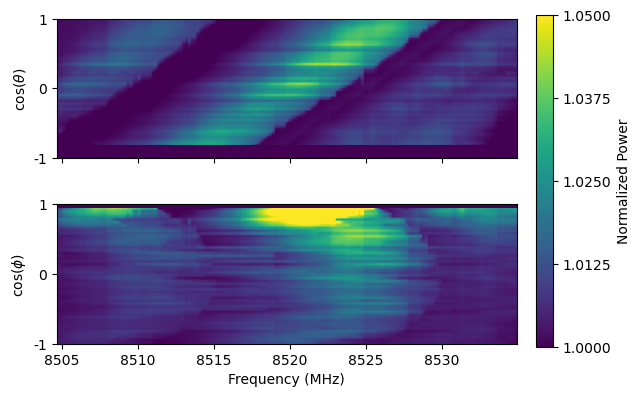

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

fig, axs = plt.subplots(2, 1)
plt.subplots_adjust(hspace=0.01)

norm = Normalize(vmin=1.00, vmax=1.05)
im0 = axs[0].imshow(theta_map, origin='lower', norm=norm)
im1 = axs[1].imshow(phi_map, origin='lower', norm=norm)
axs[0].set_ylabel('$\mathrm{cos}({\\theta})$')
axs[1].set_ylabel('$\mathrm{cos}({\phi})$')
axs[1].set_xlabel('Frequency (MHz)')
for ax in axs:
    freq_diff = xs[1] - xs[0]
    freq_diff_inv = 1 / freq_diff
    labels = np.arange(8505, 8535, 5)
    ax.set_xticks((labels - min(xs)) * (1 / freq_diff))
    ax.set_yticks([-0.5,24.5,49.5])
    ax.set_yticklabels([-1,0,1])
    ax.set_facecolor(cm.get_cmap('viridis')(0))
    # lines
    # for i in np.arange(0, 50, 5):
    #     ax.axhline(i, color='red')
axs[0].set_xticklabels([])
axs[1].set_xticklabels(labels)
cbar = fig.colorbar(im0, ax=axs.ravel().tolist(), orientation='vertical', fraction=0.0335, pad=0.04, ticks=[1.00, 1.0125, 1.025, 1.0375, 1.05])
cbar.set_label('Normalized Power')

plt.savefig('/home/bhanselman/heatmap.png')

In [ ]:
theta_map, phi_map

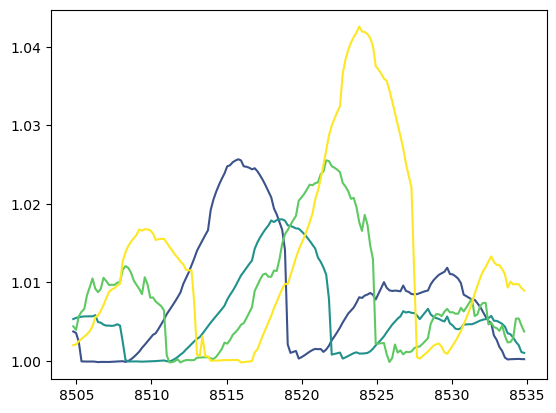

In [27]:
import matplotlib as mpl
cmap = mpl.colormaps['viridis']
color_inds = np.linspace(0, 1, 5)
colors = cmap(color_inds)
for spec, color in zip(theta_map[0::10], colors):
    plt.plot(xs, spec, color=color)

# Normalization movie! :)

In [54]:
def inject_spaced_one(signal_size, loc, spacing, path, filepath_to_save, template=False, is_decay=True):
    os.makedirs(filepath_to_save, exist_ok=True)
    def get_vals(sig_loc):
        if is_decay:
            sig_std = v_virial*sig_loc/(c*np.sqrt(3))
            sig_amp_ratio = 2.75e23*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile
            return (sig_std, sig_amp_ratio, col_name)
        else:
            sig_std = v_virial*sig_loc/(c*np.sqrt(6))
            sig_amp_ratio = 3.55e28*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile+'_sq'
            return (sig_std, sig_amp_ratio, col_name)
    targ_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv').set_index('source')

    try:
        file = np.load(path)
        spec =  file[1]
        freq = file[0]
        if template:
            spec = np.ones_like(spec)
        spec_med = np.median(spec)
        name = path.split('/')[-1]
        theta = targ_info.loc[name[:-4], 'theta']

        loc_loop = loc
        end = freq[freq.size-20]
        # salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
        while loc_loop <= end:
            sig_std, sig_amp_ratio, col_name = get_vals(loc_loop)
            amp_ratio = sig_amp_ratio*targ_info.loc[name[:-4], col_name]
            amp = spec_med*amp_ratio
            salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
            spec = salted
            loc_loop = loc_loop + spacing
        save_loc = os.path.join(filepath_to_save, name)
        print(save_loc)
        np.save(save_loc, np.array([freq, spec]))
    except Exception as e:
        print(e)  

In [55]:
injected_dir_movie = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/movie/'

In [56]:
def normalize_movie(loc, window=111, freq=None, width=200, nsigma=2, order=5, is_decay=True):
    xs, ys = np.load(os.path.join(injected_dir_movie, loc))
    freq_diff = xs[1] - xs[0]
    offset = 0
    if freq:
        #index = int((freq - xs[0]) / freq_diff)
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
        offset = 16 - (index-width) % 16
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = ys / ys.mean()
    for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma
    
    def fit_func(x, A, center, *coeffs, window_center=0):
        ''' Weighted polynomial plus Gaussian
        '''
        sigma = get_sigma(window_center + center)
        y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2))
        y += fit_func2(x, *coeffs)
        return y
        
    def fit_func2(x, *coeffs): #polynomial
        ''' 
        '''
        y = 0
        for i, coeff in enumerate(coeffs):
            y += coeff * x ** i
        return y
    
    # Center bounds
    lower_bound = -(window//2) * freq_diff
    upper_bound = (window//2+1) * freq_diff
    #print(-(window//2), (window//2+1))
    guesses = np.ones_like(range(order+1)).tolist()
    bounds = (
        (0, lower_bound, *[-np.inf for _ in guesses]),
        #(-np.inf, lower_bound, *[-np.inf for _ in guesses]),
        (np.inf, upper_bound, *[np.inf for _ in guesses])
    )
    
    normalized_spectrum = []
    pg_params = []
    p_params = []
    masks = []
    
    # Loop through the data points and divide each point by the polynomial 
    for i in range(lower, len(xs)-upper):

        #print(f'{i}/{len(xs)-upper-lower}')
        current_ys = ys_mean[i-lower:i+upper]
        idx = np.isfinite(current_ys)

        # Fit the defined function to the data using curve fitting
        fit_func_wrapper = partial(fit_func, window_center = xs[i])
        
        #polynomial + gaussian
        parameters, covariance = curve_fit(
            fit_func_wrapper,
            ind_xs[idx],
            current_ys[idx],
            p0=[2, 1, *guesses],
            bounds=bounds,
            maxfev=1000000)
        #polynomial + guassian
        # fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_= parameters

        # cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        fit_center_ = parameters[1]
        cent = fit_center_/freq_diff
        sig = nsigma * get_sigma(xs[i] + fit_center_)/freq_diff # 3 sigma 
        # xs_1 = ind_xs[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # xs_2 = ind_xs[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        # ys_1 = current_ys[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # ys_2 = current_ys[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        #sig = 12 # testing the old range
        mask1 = ind_xs[idx] < (cent - sig)
        mask2 = ind_xs[idx] > (cent + sig)
        combined_mask = mask1 | mask2
        xs_masked = ind_xs[idx][combined_mask]
        ys_masked = current_ys[idx][combined_mask]
        #print(f'Center (bins): {cent}, 3-sigma (bins): {sig}, xs: {xs_masked}')
        
        #polynomial
        # parameters2, covariance = curve_fit(fit_func2, np.concatenate((xs_1, xs_2)), np.concatenate((ys_1, ys_2)),  p0=[1,1,1,1,1,0], maxfev=1000000)
        parameters2, covariance = curve_fit(fit_func2, xs_masked, ys_masked, p0=guesses, maxfev=1000000)
        #polynomial
        # fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2      
        
        p = fit_func2(0, *parameters2)
        pg = fit_func_wrapper(0, *parameters)
        #fit_ys = fit_func(ind_xs, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
        # chi_squared = np.sum((current_ys[idx] - fit_ys[idx])**2/fit_ys[idx])
        # chi_squareds.append(chi_squared)
        normalized_spectrum.append(pg/p)
        pg_params.append(parameters)
        p_params.append(parameters2)
        masks.append(combined_mask)

    new_xs = xs[lower: len(xs)-upper]
    normalized = np.array([new_xs, normalized_spectrum])
    return normalized, pg_params, p_params, masks, ys_mean

In [57]:
is_decay = True
def get_sigma(center):
    if is_decay:
        sigma = v_virial*center/(c*np.sqrt(3))
    else:
        sigma = v_virial*center/(c*np.sqrt(6))
    return sigma

def fit_func(x, A, center, *coeffs, window_center=0):
    ''' Weighted polynomial plus Gaussian
    '''
    sigma = get_sigma(window_center + center)
    y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2))
    y += fit_func2(x, *coeffs)
    return y

def fit_func2(x, *coeffs): #polynomial
    ''' 
    '''
    y = 0
    for i, coeff in enumerate(coeffs):
        y += coeff * x ** i
    return y

In [58]:
def normalize_weighted_movie(data, a=0.1, b=1, window=261, freq=None, width=200, order=5, is_decay=True):#xs, ys, a, b, sigma, order, window, rb_size=1):
    """
    Standard rolling polynomial normalize procedure. Updated.
    """
    xs, ys = data
    freq_diff = xs[1] - xs[0]
    offset = 0
    if freq:
        #index = int((freq - xs[0]) / freq_diff)
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
        offset = 16 - (index-width) % 16
        print(offset)
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = ys / ys.mean()
    for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma

    normalized_spectrum = []
    unweighted_ps = []
    weighted_ps = []

    # Loop through the data points and divide each point by the polynomial 
    for i in range(lower, len(xs)-upper):

        current_ys = ys_mean[i-lower:i+upper]
        idx = np.isfinite(current_ys)

        # Unweighted fit
        unweighted_params = np.polyfit(ind_xs[idx], current_ys[idx], order)
        
        # Weighted fit
        sigma = get_sigma(xs[i])
        weights = 1 - a*np.exp(-(freq_diff*ind_xs[idx])**2 / (2*b*sigma**2))
        weighted_params = np.polyfit(ind_xs[idx], current_ys[idx], order, w=weights)
        
        unweighted = np.poly1d(unweighted_params)(0)
        weighted = np.poly1d(weighted_params)(0)
        
        normalized_spectrum.append(unweighted/weighted)
        unweighted_ps.append(unweighted_params)
        weighted_ps.append(weighted_params)
    
    new_xs = xs[lower: len(xs)-upper]
    #new_ys = ys_mean[lower: len(xs)-upper]
    normalized = np.array([new_xs, normalized_spectrum])
    #old = np.array([new_xs, new_ys])
    return normalized, unweighted_ps, weighted_ps, ys_mean

MovieWriter ffmpeg unavailable; using Pillow instead.


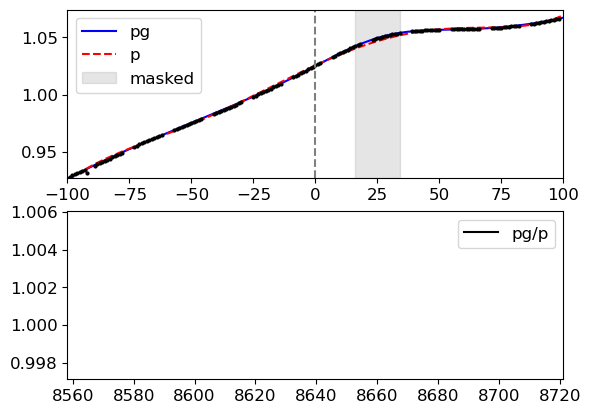

In [60]:
from matplotlib.animation import FuncAnimation
spectra = os.listdir(injected_dir) #cleaned_dir
path = spectra[0] #random.choice(spectra)
#inject_spaced_one(1e-27, 7520, 200, os.path.join(cleaned_dir, path), injected_dir_movie)

window, freq, width = 201, 8640, 100
nsigma, order = 0.5, 5

# normalized, unweighted_ps, weighted_ps, ys_mean = normalize_weighted_movie(
#     np.load(os.path.join(injected_dir_movie, path)),
#     window=window,
#     freq=freq,
#     width=width,
#     order=order,
# )
normalized, pg_params, p_params, masks, ys_mean = normalize_movie(
    os.path.join(injected_dir, path), #injected_dir_movie
    window=window,
    freq=freq,
    width=width,
    nsigma=nsigma,
    order=order,
)

freq_diff = normalized[0][1] - normalized[0][0]

fig, axs = plt.subplots(2,1)

pg, = axs[0].plot([], [], color='blue', label='pg')
p, = axs[0].plot([], [], color='red', ls='--',label='p')

window_pts, = axs[0].plot([], [], ls='', color='k', marker='o', markersize=2)
line = axs[0].axvline(0, ls='--', color='gray')
box = axs[0].axvspan(0, 0, color='gray', alpha=0.2, label='masked')

norm_spectrum, = axs[1].plot([], [], color='k', label='pg/p')

ind_xs = np.arange(-(window//2), window//2+1)
lower = (window - 1) // 2
upper = (window + 1) // 2

axs[0].set_xlim([-(window//2), window//2])
axs[0].set_ylim([min(ys_mean), max(ys_mean)])
axs[1].set_xlim([min(normalized[0]), max(normalized[0])])
axs[1].set_ylim([min(normalized[1]), max(normalized[1])]) # Might change later
axs[0].legend()
axs[1].legend()

ind_xs = np.arange(-(window//2), window//2+1)

def animate(i):
    current_ys = ys_mean[i:i+upper+lower]
    idx = np.isfinite(current_ys)
    masked = masks[i]
    window_pts.set_data(ind_xs[idx], current_ys[idx])
    xmin = ind_xs[idx][~masked][0]
    xmax = ind_xs[idx][~masked][-1]
    y_coords = box.get_xy()[:,1]
    box.set_xy([(xmin, y_coords[0]),
              (xmin, y_coords[1]),
              (xmax, y_coords[2]),
              (xmax, y_coords[3])])
    
    fit_func_wrapper = partial(fit_func, window_center = normalized[0][i])
    # sigma = get_sigma(normalized[0][i])
    # def fit_func(x, A, b,c, d, f, g, h, center):
    #     ''' Weighted polynomial plus Gaussian
    #     '''
    #     y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2)) + b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5
    #     return y

    # unweighted_params, weighted_params = unweighted_ps[i], weighted_ps[i]
    # pg.set_data(ind_xs, np.poly1d(unweighted_params)(ind_xs))
    # p.set_data(ind_xs, np.poly1d(weighted_params)(ind_xs))
    parameters, parameters2 = pg_params[i], p_params[i]
    pg.set_data(ind_xs, fit_func_wrapper(ind_xs, *parameters))
    p.set_data(ind_xs, fit_func2(ind_xs, *parameters2))
    
    norm_spectrum.set_data(normalized[0][:i], normalized[1][:i])
    
    #return window_pts, window_pts_masked, pg, p, norm_spectrum, line
    return window_pts, pg, p, norm_spectrum, line, box

anim = FuncAnimation(fig=fig, func=animate, frames=len(normalized[0]), interval=100)
anim.save('/home/bhanselman/normalized_pg_29_negative_snr.gif')

In [221]:
normalized_pg, pg_params, p_params, masks, ys_mean = normalize_movie(
    os.path.join(injected_dir_movie, path),
    window=261,
    freq=freq,
    width=width,
    nsigma=nsigma,
    order=order,
)
normalized_weighted, unweighted_ps, weighted_ps, ys_mean = normalize_weighted_movie(
    np.load(os.path.join(injected_dir_movie, path)),
    window=261,
    freq=freq,
    width=width,
    order=order,
)

4


Text(0.5, 1.0, 'Weighted')

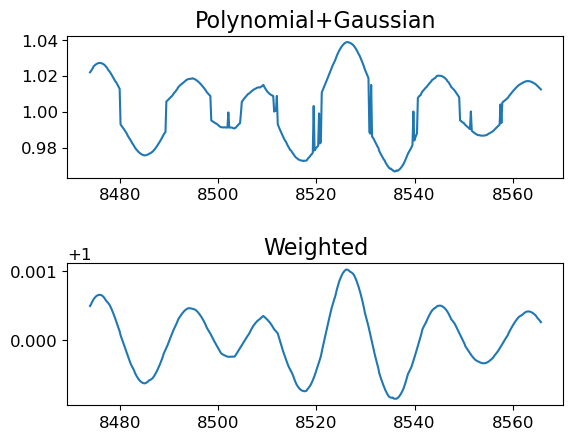

In [222]:
fig, axs = plt.subplots(2, 1)
plt.subplots_adjust(hspace=0.6)
axs[0].plot(*normalized_pg)
axs[0].set_title('Polynomial+Gaussian')
axs[1].plot(*normalized_weighted)
axs[1].set_title('Weighted')

In [17]:
why = Spectrum(os.path.join(cleaned_dir, path), interpret=False)

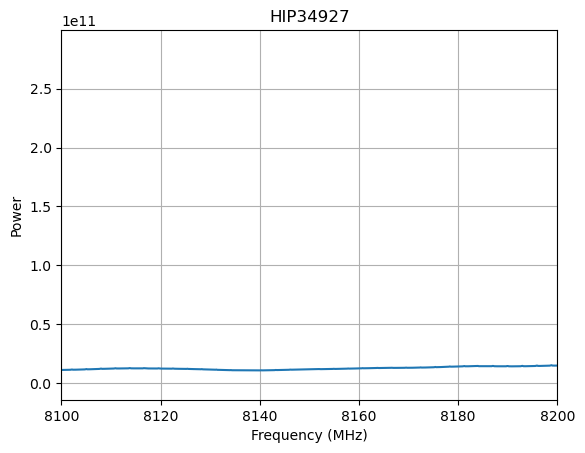

In [20]:
why.plot(xlim=(8100,8200))

### Movie code for old normalization

In [14]:
def normalize_movie_old(loc, window=111, freq=None, width=200, is_decay=True):
    xs, ys = np.load(os.path.join(injected_dir_movie, loc))
    freq_diff = xs[1] - xs[0]
    if freq:
        index = int((freq - xs[0]) / freq_diff)
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = ys / ys.mean()
    chi_squareds = []
    for i in range(16, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def fit_func(x, A, b,c, d, f, g, h, center):
        ''' Weighted polynomial plus Gaussian
        '''
        y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2)) + b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5
        return y
        
    def fit_func2(x, b,c, d, f, g, h): #polynomial
        ''' 
        '''
        y = b + c*x + d*x**2 + f*x**3 + g*x**4 + h*x**5
        return y
    normalized_spectrum = []
    pg_params = []
    p_params = []
    masks = []
    # Loop through the data points and divide each point by the polynomial 
    for i in range(lower, len(xs)-upper):
        if is_decay:
            sigma = v_virial*xs[i]/(c*np.sqrt(3))
        else:
            sigma = v_virial*xs[i]/(c*np.sqrt(6))
        
        current_ys = ys_mean[i-lower:i+upper]
        idx = np.isfinite(current_ys)

        # Fit the defined function to the data using curve fitting

        #polynomial + gaussian
        parameters, covariance = curve_fit(fit_func, ind_xs[idx], current_ys[idx],  p0=[2, 1,1,1,1,1,1, 0], maxfev=1000000)
        #polynomial + guassian
        fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_= parameters

        # # cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        # cent = fit_center_/freq_diff
        # sig = 3 * get_sigma(xs[i] + fit_center_)/freq_diff # 3 sigma 
        # # xs_1 = ind_xs[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # # xs_2 = ind_xs[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        # # ys_1 = current_ys[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # # ys_2 = current_ys[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        # mask1 = ind_xs[idx] < (cent - sig)
        # mask2 = ind_xs[idx] > (cent + sig)
        # combined_mask = mask1 | mask2
        # xs_masked = ind_xs[idx][combined_mask]
        # ys_masked = current_ys[idx][combined_mask]
        # #print(f'Center (bins): {cent}, 3-sigma (bins): {sig}, xs: {xs_masked}')
        
        cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        xs_1 = ind_xs[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-12)))]
        xs_2 = ind_xs[idx][np.argmin(np.abs(ind_xs[idx] - (cent+12))):]
        ys_1 = current_ys[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-12)))]
        ys_2 = current_ys[idx][np.argmin(np.abs(ind_xs[idx] - (cent+12))):]
        #polynomial
        parameters2, covariance = curve_fit(fit_func2, np.concatenate((xs_1, xs_2)), np.concatenate((ys_1, ys_2)),  p0=[1,1,1,1,1,0], maxfev=1000000)
        #polynomial
        fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2        
        
        p = fit_func2(0, fit_b,fit_c, fit_d, fit_f, fit_g, fit_h)
        pg = fit_func(0, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
        fit_ys = fit_func(ind_xs, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
        # chi_squared = np.sum((current_ys[idx] - fit_ys[idx])**2/fit_ys[idx])
        # chi_squareds.append(chi_squared)
        normalized_spectrum.append(pg/p)
        pg_params.append(parameters)
        p_params.append(parameters2)
        #masks.append(combined_mask)

    new_xs = xs[lower: len(xs)-upper]
    normalized = np.array([new_xs, normalized_spectrum])
    return normalized, pg_params, p_params, ys_mean

## Updated normalization movie for dynamic window

In [2]:
class DynamicNormalizedSpectrum:
    C = 299792
    V_VIRIAL = 250 # km/s
    
    def __init__(self,
                 path,
                 window_factor=0.02,
                 freq=None,
                 width=200,
                 nsigma=2,
                 order=5,
                 is_decay=True):
        self.is_decay = is_decay
        self.window_factor = window_factor
        self.nsigma = nsigma
        
        xs, ys = np.load(path)
        self.freq_diff = xs[1] - xs[0]
        offset = 0
        if freq:
            index = np.argmin(np.abs(xs - freq))
            width = int(width / self.freq_diff)
            xs = xs[index-width:index+width]
            ys = ys[index-width:index+width]
            offset = 16 - (index-width) % 16

        ys_mean = ys / ys.mean()
        for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
            ys_mean[i] = np.NaN
            ys_mean[i+15] = np.NaN
            ys_mean[i+1] = np.NaN
            ys_mean[i+14] = np.NaN

        new_xs = []
        normalized_spectrum = []
        pg_params = []
        p_params = []
        
        print('Normalizing spectrum...')
        # Loop through the data points and divide each point by the polynomial 
        for i, x in enumerate(xs):
            window = self._round_up_to_nearest_odd(window_factor * x)
            if i < (window//2):
                continue
            if i > len(xs) - (window//2 + 1):
                break
            ind_xs = np.arange(-(window//2), window//2+1)
            #print(f'{i}/{len(xs)-upper-lower}')
            current_ys = ys_mean[i-window//2:i+window//2+1]
            idx = np.isfinite(current_ys)

            # Center bounds
            lower_bound = -(window//2) * self.freq_diff
            upper_bound = (window//2) * self.freq_diff
            guesses = np.ones_like(range(order+1)).tolist()
            bounds = (
                (0, lower_bound, *[-np.inf for _ in guesses]),
                (np.inf, upper_bound, *[np.inf for _ in guesses])
            )

            # Fit the defined function to the data using curve fitting
            fit_func_wrapper = partial(self._poly_gaussian, window_center = x)
            #polynomial + gaussian
            parameters, covariance = curve_fit(
                fit_func_wrapper,
                ind_xs[idx],
                current_ys[idx],
                p0=[2, 1, *guesses],
                bounds=bounds,
                maxfev=1000000)
            #polynomial + guassian

            fit_center_ = parameters[1]
            cent = fit_center_ / self.freq_diff
            sig = nsigma * self._get_sigma(x + fit_center_) / self.freq_diff # 3 sigma 
            mask1 = ind_xs[idx] < (cent - sig)
            mask2 = ind_xs[idx] > (cent + sig)
            combined_mask = mask1 | mask2
            xs_masked = ind_xs[idx][combined_mask]
            ys_masked = current_ys[idx][combined_mask]

            #polynomial
            parameters2, covariance = curve_fit(self._poly, xs_masked, ys_masked, p0=guesses, maxfev=1000000)   

            p = self._poly(0, *parameters2)
            pg = fit_func_wrapper(0, *parameters)
            new_xs.append(x)
            normalized_spectrum.append(pg/p)
            pg_params.append(parameters)
            p_params.append(parameters2)
        
        self.spectrum = np.array([xs, ys])
        self.mean_spectrum = np.array([xs, ys_mean])
        self.norm_spectrum = np.array([new_xs, normalized_spectrum])
        self.pg_params = pg_params
        self.p_params = p_params
        
        print('Normalization complete!')
    
    def _round_up_to_nearest_odd(self, number):
        ceiled_number = math.ceil(number)
        return int(ceiled_number + 1) if ceiled_number % 2 == 0 else int(ceiled_number)
    
    def _get_sigma(self, center):
        c, v_virial = DynamicNormalizedSpectrum.C, DynamicNormalizedSpectrum.V_VIRIAL
        if self.is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma

    def _poly_gaussian(self, x, A, center, *coeffs, window_center=0):
        ''' Weighted polynomial plus Gaussian
        '''
        sigma = self._get_sigma(window_center + center)
        y = (A**2)*np.exp((-(self.freq_diff*x-center)**2)/(2*sigma**2))
        y += self._poly(x, *coeffs)
        return y

    def _poly(self, x, *coeffs): #polynomial
        ''' 
        '''
        y = 0
        for i, coeff in enumerate(coeffs):
            y += coeff * x ** i
        return y
    
    def get_spectrum(self):
        return self.spectrum
    
    def get_norm_spectrum(self):
        return self.norm_spectrum
    
    def generate_movie(self, save_dir=None):
        from matplotlib.animation import FuncAnimation

        ######## INITIALIZE THE PLOT ########
    
        fig, axs = plt.subplots(2, 1, sharex=True)
        plt.subplots_adjust(wspace=0)

        pg, = axs[0].plot([], [], color='blue', label='pg')
        p, = axs[0].plot([], [], color='red', ls='--',label='p')

        line_0 = axs[0].axvline(0, ls='--', color='k')
        line_1 = axs[1].axvline(0, ls='--', color='k')

        window_box = axs[0].axvspan(0, 0, color='blue', alpha=0.2, label='window')
        masked_box = axs[0].axvspan(0, 0, color='gray', alpha=0.2, label='masked')

        norm_spectrum, = axs[1].plot([], [], color='k', label='pg/p')
        
        xs, ys_mean = self.mean_spectrum
        idx = np.isfinite(ys_mean)
        xs_norm, ys_norm = self.norm_spectrum
        
        axs[0].set_xlim(xs[0], xs[-1])
        axs[0].set_ylim([min(ys_mean), max(ys_mean)])
        axs[1].set_xlim(xs[0], xs[-1])
        axs[1].set_ylim([min(ys_norm), max(ys_norm)])
        axs[0].legend(loc='upper right')
        axs[1].legend()

        #####################################
        
        def draw():
            spectrum, = axs[0].plot(xs[idx], ys_mean[idx], ls='', color='k', marker='o', markersize=1)
            box1 = axs[1].axvspan(min(xs), min(xs_norm), color='gray')
            box2 = axs[1].axvspan(max(xs_norm), max(xs), color='gray')
            return spectrum, box1, box2
            
        def animate(i):
            x = xs_norm[i]
            window = self._round_up_to_nearest_odd(self.window_factor * x)
            xmin = x - (window//2) * self.freq_diff
            xmax = x + (window//2) * self.freq_diff
            y_coords = window_box.get_xy()[:,1]
            window_box.set_xy([(xmin, y_coords[0]),
                              (xmin, y_coords[1]),
                              (xmax, y_coords[2]),
                              (xmax, y_coords[3])])
                        
            i_prime = xs.tolist().index(x)
            full_ind_xs = np.arange(-i_prime, len(xs)-i_prime)
            
            fit_center_ = self.pg_params[i][1]
            cent = fit_center_ / self.freq_diff
            sig = self.nsigma * self._get_sigma(x + fit_center_) / self.freq_diff # 3 sigma 
            mask1 = full_ind_xs > (cent - sig)
            mask2 = full_ind_xs < (cent + sig)
            combined_mask = mask1 & mask2
            xs_masked = xs[combined_mask]
            xmin_masked, xmax_masked = xs_masked[0], xs_masked[-1]
            y_coords = masked_box.get_xy()[:,1]
            masked_box.set_xy([(xmin_masked, y_coords[0]),
                              (xmin_masked, y_coords[1]),
                              (xmax_masked, y_coords[2]),
                              (xmax_masked, y_coords[3])])

            fit_func_wrapper = partial(self._poly_gaussian, window_center=x)
            parameters, parameters2 = self.pg_params[i], self.p_params[i]
            pg.set_data(xs, fit_func_wrapper(full_ind_xs, *parameters))
            p.set_data(xs, self._poly(full_ind_xs, *parameters2))

            norm_spectrum.set_data(xs_norm[:i], ys_norm[:i])
            
            line_0.set_xdata([x, x])
            line_1.set_xdata([x, x])
            
            #return window_pts, window_pts_masked, pg, p, norm_spectrum, line
            return pg, p, norm_spectrum, line_0, line_1, window_box, masked_box
        
        print('Writing gif...')
        anim = FuncAnimation(fig=fig,
                             func=animate,
                             init_func=draw,
                             frames=len(xs_norm),
                             interval=100,
                             blit=True)
        if save_dir:
            save_dir_head = save_dir.replace(save_dir.split('/')[-1], '')
            os.makedirs(save_dir_head, exist_ok=True)
        else:
            save_dir = 'norm.gif'
        anim.save(save_dir, dpi=500)
        print('gif saved!')

In [ ]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/2/preprocessed_despiked/'
name = os.listdir(data_dir)[0]
path = os.path.join(data_dir, name)
save_dir = f'/home/bhanselman/movies/11080_dynamic_{name}.gif'

norm = DynamicNormalizedSpectrum(path,
                                 nsigma=1.5,
                                 window_factor=0.0275,
                                 freq=11080,
                                 width=70)
norm.generate_movie(save_dir=save_dir)

Normalizing spectrum...
Normalization complete!
Writing gif...


MovieWriter ffmpeg unavailable; using Pillow instead.


### Testing my module

In [3]:
os.chdir('/home/bhanselman/scripts')
from movies import NormalizedSpectrum

data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/asymmetry_tests/8670_1e29_lowguess_check/injected/'
#'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/2'

targets = []
ddir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/'
with open(os.path.join(ddir, 'snr_targets_200.txt'), 'r') as file:
    for line in file:
        targets.append(line.strip())

targs = [targ + '.npy' for targ in targets if targ + '.npy' in os.listdir(data_dir)]

2


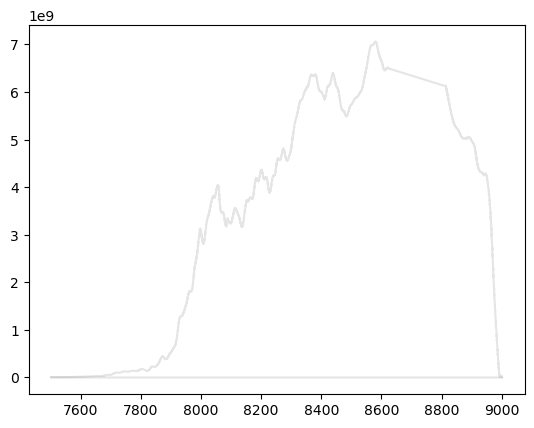

In [ ]:
count = 0
for targ in os.listdir(data_dir):
    spec = np.load(os.path.join(data_dir, targ))
    if (spec[0][0]<7600):
        plt.plot(*spec, c='k', alpha=0.1)
        count += 1
        
print(count)

Normalizing spectrum...
Normalization complete!
Writing gif...


MovieWriter ffmpeg unavailable; using Pillow instead.


gif saved!


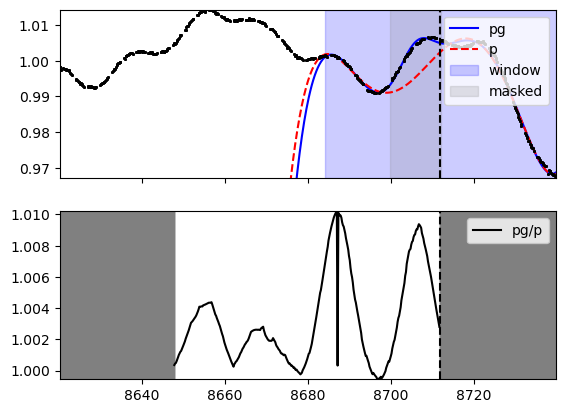

In [4]:
name = targs[1]
path = os.path.join(data_dir, name)
save_dir = f'/home/bhanselman/movies/8670_presentation.gif'

norm = NormalizedSpectrum(path,
                          freq=8680,
                          width=60,
                          nsigma=1.5,
                          window_factor=0.035,
                          order=5)
norm.generate_movie(save_dir=save_dir)
                                 

# SNR optimization (old)

## Functions

In [21]:
def inject_spaced_one_for_snr(signal_size, loc, spacing, path, template=False, is_decay=True):
    def get_vals(sig_loc):
        if is_decay:
            sig_std = v_virial*sig_loc/(c*np.sqrt(3))
            sig_amp_ratio = 2.75e23*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile
            return (sig_std, sig_amp_ratio, col_name)
        else:
            sig_std = v_virial*sig_loc/(c*np.sqrt(6))
            sig_amp_ratio = 3.55e28*signal_size / (v_virial*(sig_loc/1e3)**4) # convert MHz to GHz
            col_name = dm_profile+'_sq'
            return (sig_std, sig_amp_ratio, col_name)
    targ_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv').set_index('source')

    try:
        file = np.load(path)
        spec =  file[1]
        freq = file[0]
        if template:
            spec = np.ones_like(spec)
        spec_med = np.median(spec)
        name = path.split('/')[-1]
        theta = targ_info.loc[name[:-4], 'theta']

        loc_loop = loc
        end = freq[freq.size-20]
        # salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
        while loc_loop <= end:
            sig_std, sig_amp_ratio, col_name = get_vals(loc_loop)
            amp_ratio = sig_amp_ratio*targ_info.loc[name[:-4], col_name]
            amp = spec_med*amp_ratio
            salted = inject(freq, spec, theta, loc_loop, signal_size, v_earth, v_virial, is_decay, name, targ_info, amp, sig_std)
            spec = salted
            loc_loop = loc_loop + spacing
        # save_loc = os.path.join(filepath_to_save, name)
        # print(save_loc)
        # np.save(save_loc, np.array([freq, spec]))
        return np.array([freq, spec])
    except Exception as e:
        print(e)

In [44]:
def normalize_for_snr(data, window=261, freq=None, width=200, nsigma=2, order=5, is_decay=True):
    xs, ys = data
    freq_diff = xs[1] - xs[0]
    offset = 0
    if freq:
        index = np.argmin(np.abs(xs - freq))
        width = int(width / freq_diff)
        xs = xs[index-width:index+width]
        ys = ys[index-width:index+width]
        offset = 16 - (index-width) % 16
    ind_xs = np.arange(-(window//2), window//2+1)
    lower = (window - 1) // 2
    upper = (window + 1) // 2
    ys_mean = ys / ys.mean()
    for i in range(offset, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys_mean[i] = np.NaN
        ys_mean[i+15] = np.NaN
        ys_mean[i+1] = np.NaN
        ys_mean[i+14] = np.NaN
    
    def get_sigma(center):
        if is_decay:
            sigma = v_virial*center/(c*np.sqrt(3))
        else:
            sigma = v_virial*center/(c*np.sqrt(6))
        return sigma
    
    def fit_func(x, A, center, *coeffs, window_center=0):
        ''' Weighted polynomial plus Gaussian
        '''
        sigma = get_sigma(window_center + center)
        y = (A**2)*np.exp((-(freq_diff*x-center)**2)/(2*sigma**2)) #A
        y += fit_func2(x, *coeffs)
        return y
        
    def fit_func2(x, *coeffs): #polynomial
        ''' 
        '''
        y = 0
        for i, coeff in enumerate(coeffs):
            y += coeff * x ** i
        return y

    normalized_spectrum = []
    # Center bounds
    lower_bound = -(window//2) * freq_diff
    upper_bound = (window//2+1) * freq_diff
    #print(-(window//2), (window//2+1))
    guesses = np.ones_like(range(order+1)).tolist()
    bounds = (
        (0, lower_bound, *[-np.inf for _ in guesses]),
        #(-np.inf, lower_bound, *[-np.inf for _ in guesses]),
        (np.inf, upper_bound, *[np.inf for _ in guesses])
    )
    
    # Loop through the data points and divide each point by the polynomial 
    for i in range(lower, len(xs)-upper):
        
        #print(f'{i}/{len(xs)-upper-lower}')
        current_ys = ys_mean[i-lower:i+upper]
        idx = np.isfinite(current_ys)

        # Fit the defined function to the data using curve fitting
        fit_func_wrapper = partial(fit_func, window_center = xs[i])

        #polynomial + gaussian
        parameters, covariance = curve_fit(
            fit_func_wrapper,
            ind_xs[idx],
            current_ys[idx],
            p0=[2, 1, *guesses],
            bounds=bounds,
            maxfev=1000000)
        #polynomial + guassian
        # fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_= parameters

        # cent = ind_xs[np.argmin(np.abs(ind_xs-fit_center_/freq_diff))]
        fit_center_ = parameters[1]
        cent = fit_center_/freq_diff
        sig = nsigma * get_sigma(xs[i] + fit_center_)/freq_diff # 3 sigma 
        # xs_1 = ind_xs[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # xs_2 = ind_xs[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        # ys_1 = current_ys[idx][:np.argmin(np.abs(ind_xs[idx] - (cent-sig)))]
        # ys_2 = current_ys[idx][np.argmin(np.abs(ind_xs[idx] - (cent+sig))):]
        #sig = 12 # testing the old range
        mask1 = ind_xs[idx] < (cent - sig)
        mask2 = ind_xs[idx] > (cent + sig)
        combined_mask = mask1 | mask2
        xs_masked = ind_xs[idx][combined_mask]
        ys_masked = current_ys[idx][combined_mask]
        #print(f'Center (bins): {cent}, 3-sigma (bins): {sig}, xs: {xs_masked}')
        
        #polynomial
        # parameters2, covariance = curve_fit(fit_func2, np.concatenate((xs_1, xs_2)), np.concatenate((ys_1, ys_2)),  p0=[1,1,1,1,1,0], maxfev=1000000)
        parameters2, covariance = curve_fit(fit_func2, xs_masked, ys_masked, p0=guesses, maxfev=1000000)
        #polynomial
        # fit_b, fit_c, fit_d, fit_f, fit_g, fit_h = parameters2      
        
        p = fit_func2(0, *parameters2)
        pg = fit_func_wrapper(0, *parameters)
        #fit_ys = fit_func(ind_xs, fit_A_, fit_b_, fit_c_, fit_d_, fit_f_, fit_g_, fit_h_, fit_center_)
        # chi_squared = np.sum((current_ys[idx] - fit_ys[idx])**2/fit_ys[idx])
        # chi_squareds.append(chi_squared)
        normalized_spectrum.append(pg/p)
    
    new_xs = xs[lower: len(xs)-upper]
    normalized = np.array([new_xs, normalized_spectrum])
    #np.save(os.path.join(normalized_dir, loc), normalized)
    return normalized

In [14]:
def calculate_snr(uninjected, injected, freq, shift, noise_window=None, **kwargs):
    xs, un_ys = normalize_for_snr(uninjected, freq=freq, **kwargs) 
    xs, ys = normalize_for_snr(injected, freq=freq, **kwargs)
    freq_diff = xs[1] - xs[0]
    # Calculate signal amplitude
    sig_loc = int((freq*shift - xs[0]) / freq_diff)
    signal = ys[sig_loc]
    # Calculate noise
    if noise_window is None:
        noise = np.std(un_ys)
    else:
        mask1 = xs >= noise_window[0]
        mask2 = xs <= noise_window[1]
        mask = mask1 & mask2
        window = un_ys[mask]
        noise = np.std(window)
    # Return SNR
    return signal / noise

## Finding the best noise window

In [59]:
snr_path = os.path.join(cleaned_dir, spectra[0])

import time
start = time.time()
normalized = normalize_for_snr(np.load(snr_path), freq=8520, width=140)
end = time.time()
print(f'Time: {end - start}')

Time: 58.436593532562256


(0.95, 1.05)

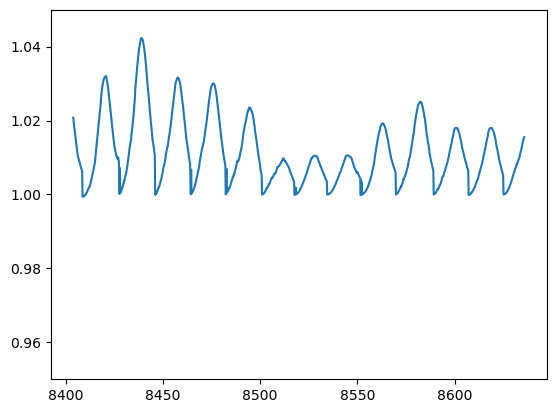

In [60]:
plt.plot(normalized[0], normalized[1])
#plt.xlim(8500,8540)
plt.ylim(0.95,1.05)

(array([279., 276., 253., 140., 124.,  82.,  41.,  45.,   9.,  18.]),
 array([0.99938883, 1.00368039, 1.00797195, 1.01226351, 1.01655508,
        1.02084664, 1.0251382 , 1.02942976, 1.03372132, 1.03801289,
        1.04230445]),
 <BarContainer object of 10 artists>)

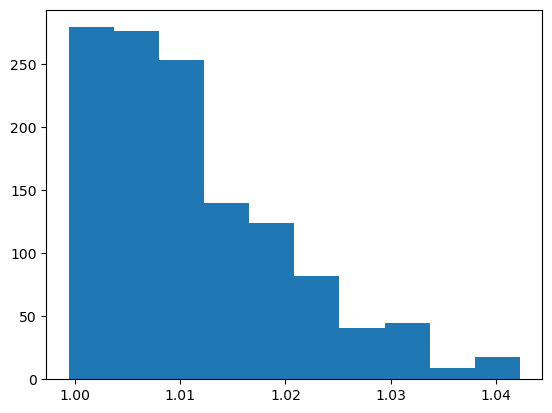

In [61]:
# Histogram of the "noise"
plt.hist(normalized[1])

## Running

In [62]:
import itertools
params = list(itertools.product(np.arange(3, 6), np.arange(0.6, 2.6, 0.2), np.arange(161, 311, 10))) # order, blanked, window

In [63]:
# Signal frequency
targ_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv').set_index('source')
name = path.split('/')[-1]
theta = targ_info.loc[name[:-4], 'theta']
shift = get_shift_factor(theta, v_earth)
shift

1.0006913143635299

In [64]:
# uninjected and injected arrays
uninjected = np.load(snr_path)
injected = inject_spaced_one_for_snr(1e-27, freq, 200, snr_path)

In [ ]:
import gc

freq, width = 8520, 100

def wrapper(args):
    order, nsigma, window = args
    gc.collect()
    return calculate_snr(uninjected, injected, freq, shift, width=width, order=order, nsigma=nsigma, window=window)

with Pool() as p:
    result = list(tqdm(p.imap(wrapper, params), total=len(params)))

  0%|          | 0/450 [00:00<?, ?it/s]

In [ ]:
np.save('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/snrs.npy', np.array(result))

In [ ]:
result_grid = np.array(result).reshape((3,15,10))

In [ ]:
xx,yy = np.meshgrid(np.arange(0.6, 2.6, 0.2), np.arange(161, 311, 10))
xx,yy

In [ ]:
result_grid[0]

In [ ]:
from matplotlib import cm
from matplotlib.colors import Normalize
fig, axs = plt.subplots(1, 3, figsize=(18,6), subplot_kw={'projection':'3d'})
plt.subplots_adjust(hspace=1)
norm = Normalize(vmin=np.min(result_grid), vmax=np.max(result_grid))

for ax, zz, order in zip(axs, result_grid, np.arange(3,6)):
    surf = ax.plot_surface(xx, yy, zz, cmap=cm.viridis, norm=norm, linewidth=0, antialiased=False)
    ax.set_zlim(np.min(result_grid), np.max(result_grid))
    ax.set_title(f'Order {order}')
axs[0].set_xlabel('$\sigma$')
axs[0].set_ylabel('window')
axs[0].set_zlabel('SNR')
cax = fig.add_axes([0.25,0.09,0.5,0.04])
cbar = fig.colorbar(surf, cax=cax, norm=norm, cmap='viridis',
             label='SNR', orientation='horizontal')
plt.savefig('/home/bhanselman/snr_plot.png')

In [ ]:
fig2d, ax = plt.subplots()
ax.contourf(xx,yy,result_grid[2],cmap='viridis')
plt.savefig('/home/bhanselman/contour.png')

In [ ]:
list(zip(params, result))

# SNR optimization (new)

In [76]:
name = spectra[0]
cleaned_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/cleaned_g/'
injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/injected_comparison/'
uninj_path = os.path.join(cleaned_dir, name)
inj_path = os.path.join(injected_dir, name)

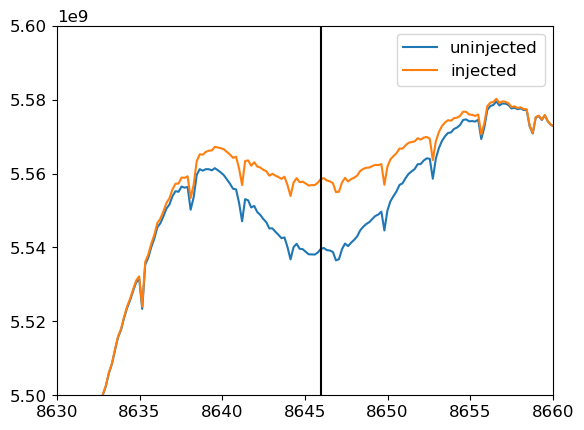

In [77]:
plt.plot(*np.load(uninj_path), label='uninjected')
plt.plot(*np.load(inj_path), label='injected')
plt.xlim(8630,8660)
plt.ylim(5.5e9,5.6e9)
freqs = [8645.972956100899, 8686.00060867544, 8726.028261249981]
for freq in freqs: plt.axvline(freq, c='k')
plt.legend()

In [78]:
from itertools import product
pg_settings = list(product(np.arange(0.5, 3.0, 0.5), np.arange(131, 281, 30)))
weighted_settings = list(product(np.arange(0.05, 1.00, 0.05), np.arange(131, 281, 30)))

In [79]:
targ_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv').set_index('source')
theta = targ_info.loc[name[:-4], 'theta']

freqs = [8640.0, 8680.0, 8720.0]
shift = get_shift_factor(theta, v_earth)
freqs_shifted = [freq * shift for freq in freqs]
freqs_shifted

[8645.972956100899, 8686.00060867544, 8726.028261249981]

In [80]:
def calculate_snr_multi(normalize_func, uninjected, injected, freqs, return_std=False, center=8520, noise_window=None, **kwargs):
    xs, un_ys = normalize_func(uninjected, freq=center, **kwargs)
    
    # Calculate noise
    if noise_window is None:
        noise = np.std(un_ys)
    else:
        mask1 = xs >= noise_window[0]
        mask2 = xs <= noise_window[1]
        mask = mask1 & mask2
        window = un_ys[mask]
        noise = np.std(window)
    
    if return_std:
        return noise
    
    xs, ys = normalize_func(injected, freq=center, **kwargs)
    # freq_diff = xs[1] - xs[0]
    # Calculate signal amplitude
    sig_locs = [np.argmin(np.abs(xs-freq)) for freq in freqs]
    signals = ys[sig_locs] - 1
    
    # Return SNR
    return [signal / noise for signal in signals]

In [81]:
import gc
from functools import partial

def wrapper(args, normalized_func_name):
    if normalized_func_name == 'pg':
        nsigma, window = args
        return calculate_snr_multi(
            normalize_for_snr,
            np.load(uninj_path),
            np.load(inj_path),
            freqs_shifted,
            center=8680,
            width=100,
            nsigma=nsigma,
            window=window,
            order=5,
        )
    a, window = args
    return calculate_snr_multi(
        normalize_weighted,
        np.load(uninj_path),
        np.load(inj_path),
        freqs_shifted,
        center=8680,
        width=100,
        a=a,
        window=window,
        order=5
    )


with Pool() as p:
    pg_partial = partial(wrapper, normalized_func_name='pg')
    weighted_partial = partial(wrapper, normalized_func_name='weighted')
    pg_results = list(tqdm(p.imap(pg_partial, pg_settings), total=len(pg_settings)))
    weighted_results = list(tqdm(p.imap(weighted_partial, weighted_settings), total=len(weighted_settings)))

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/95 [00:00<?, ?it/s]

In [82]:
np.save('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/pg_snrs_28.npy', np.array(pg_results))
np.save('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/w_snrs_28.npy', np.array(weighted_results))

In [83]:
list(zip(pg_settings, pg_results)), list(zip(weighted_settings, weighted_results))

([((0.5, 131), [-0.26310083663853717, 3.0646312081068996, 1.915927571773951]),
  ((0.5, 161), [-0.5407731695396621, 2.7214692414181996, 2.073896911467999]),
  ((0.5, 191), [-0.6176559423160439, 2.255134861052268, 1.8726844424213374]),
  ((0.5, 221), [-0.6120748180120028, 2.1575226600325195, 1.7503835476513983]),
  ((0.5, 251), [-0.5333932992939261, 2.215992405043813, 1.796294403805334]),
  ((1.0, 131), [0.2521245554418828, 3.5709059723561265, 3.582071614410683]),
  ((1.0, 161),
   [-0.0006774995255756803, 3.433456769884494, 3.0899617655757496]),
  ((1.0, 191), [-0.31613071937133086, 2.7480742330421366, 2.616552469450489]),
  ((1.0, 221), [-0.26566614511043174, 2.4385271826161286, 2.3929218081319723]),
  ((1.0, 251), [-0.30363331954199063, 2.476865051975758, 2.273514943726182]),
  ((1.5, 131), [1.2675672746582922, 3.205117563873279, 3.2464911333424262]),
  ((1.5, 161), [0.44725730244049117, 3.8269033031251523, 3.1168691664206456]),
  ((1.5, 191), [0.16557048635555188, 3.072152968295239,

In [84]:
pg_xx, pg_yy = np.meshgrid(np.arange(0.5, 3.0, 0.5), np.arange(131, 281, 30), indexing='ij')
weighted_xx, weighted_yy = np.meshgrid(np.arange(0.05, 1.00, 0.05), np.arange(131, 281, 30), indexing='ij')
pg_xx, pg_yy, weighted_xx, weighted_yy

(array([[0.5, 0.5, 0.5, 0.5, 0.5],
        [1. , 1. , 1. , 1. , 1. ],
        [1.5, 1.5, 1.5, 1.5, 1.5],
        [2. , 2. , 2. , 2. , 2. ],
        [2.5, 2.5, 2.5, 2.5, 2.5]]),
 array([[131, 161, 191, 221, 251],
        [131, 161, 191, 221, 251],
        [131, 161, 191, 221, 251],
        [131, 161, 191, 221, 251],
        [131, 161, 191, 221, 251]]),
 array([[0.05, 0.05, 0.05, 0.05, 0.05],
        [0.1 , 0.1 , 0.1 , 0.1 , 0.1 ],
        [0.15, 0.15, 0.15, 0.15, 0.15],
        [0.2 , 0.2 , 0.2 , 0.2 , 0.2 ],
        [0.25, 0.25, 0.25, 0.25, 0.25],
        [0.3 , 0.3 , 0.3 , 0.3 , 0.3 ],
        [0.35, 0.35, 0.35, 0.35, 0.35],
        [0.4 , 0.4 , 0.4 , 0.4 , 0.4 ],
        [0.45, 0.45, 0.45, 0.45, 0.45],
        [0.5 , 0.5 , 0.5 , 0.5 , 0.5 ],
        [0.55, 0.55, 0.55, 0.55, 0.55],
        [0.6 , 0.6 , 0.6 , 0.6 , 0.6 ],
        [0.65, 0.65, 0.65, 0.65, 0.65],
        [0.7 , 0.7 , 0.7 , 0.7 , 0.7 ],
        [0.75, 0.75, 0.75, 0.75, 0.75],
        [0.8 , 0.8 , 0.8 , 0.8 , 0.8 ],
      

In [85]:
pg_results_zipped, weighted_results_zipped = list(zip(*pg_results)), list(zip(*weighted_results))
pg_results_grids = [np.array(a).reshape(pg_xx.shape) for a in pg_results_zipped]
weighted_results_grids = [np.array(a).reshape(weighted_xx.shape) for a in weighted_results_zipped]
pg_results_grids, weighted_results_grids

([array([[-2.63100837e-01, -5.40773170e-01, -6.17655942e-01,
          -6.12074818e-01, -5.33393299e-01],
         [ 2.52124555e-01, -6.77499526e-04, -3.16130719e-01,
          -2.65666145e-01, -3.03633320e-01],
         [ 1.26756727e+00,  4.47257302e-01,  1.65570486e-01,
           1.46133765e-02, -8.11791561e-02],
         [-1.38657180e+00,  9.70489456e-01,  5.01123759e-01,
           2.71982795e-01,  1.83550513e-01],
         [-4.17547010e-03,  3.37391575e+00, -4.89625174e-01,
           5.53359572e-01,  3.75777197e-01]]),
  array([[3.06463121e+00, 2.72146924e+00, 2.25513486e+00, 2.15752266e+00,
          2.21599241e+00],
         [3.57090597e+00, 3.43345677e+00, 2.74807423e+00, 2.43852718e+00,
          2.47686505e+00],
         [3.20511756e+00, 3.82690330e+00, 3.07215297e+00, 2.87301879e+00,
          2.91196630e+00],
         [2.40072812e-01, 3.30063114e+00, 3.20136393e+00, 3.07610503e+00,
          3.16717203e+00],
         [3.07363071e-03, 6.57749024e-01, 2.00249828e+00, 2.8209

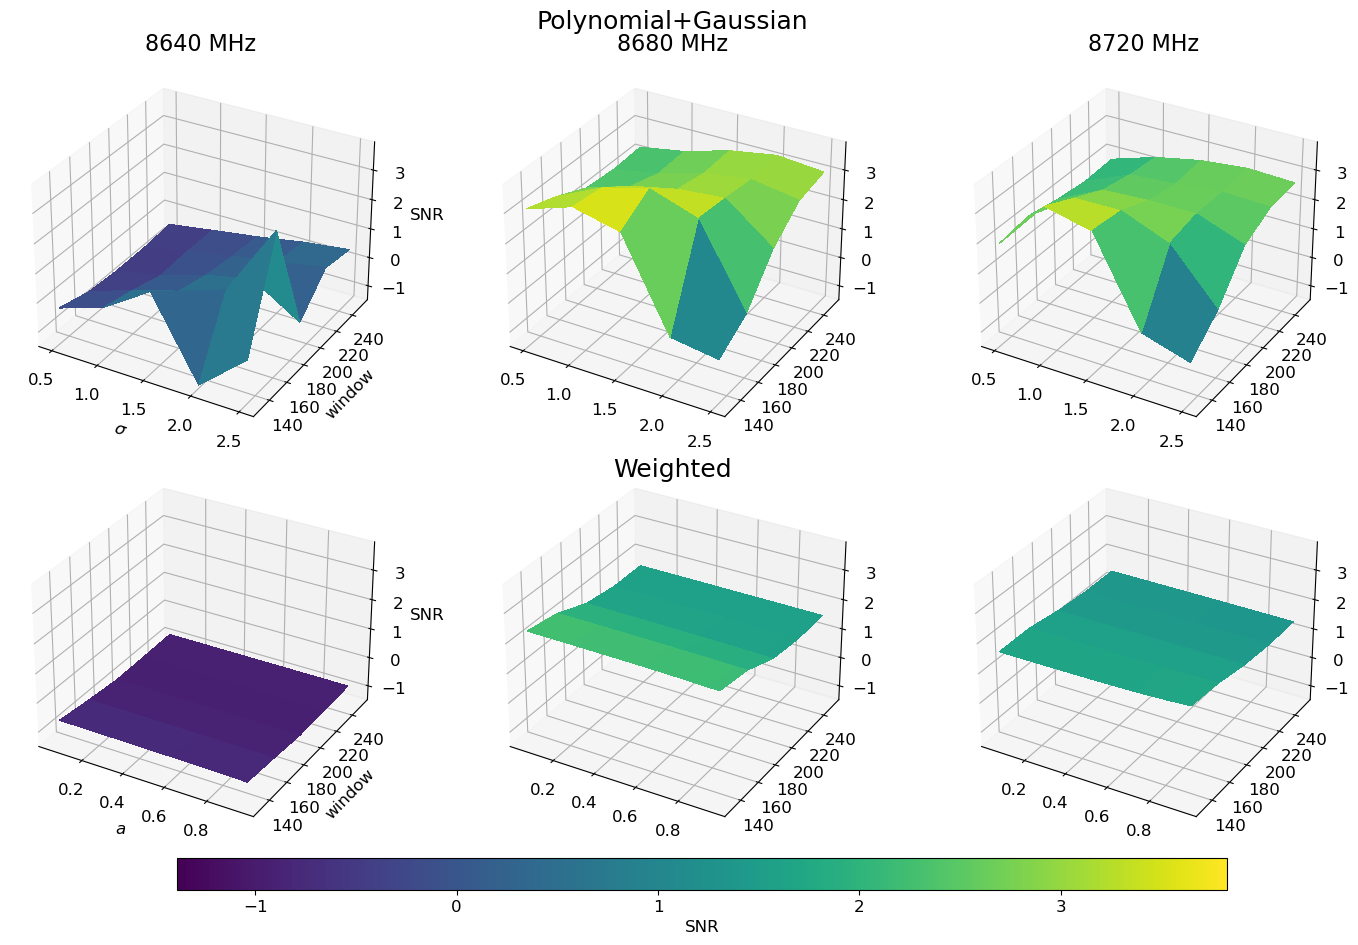

In [86]:
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.titlesize': 18})

fig = plt.figure(figsize=(15,8))
(pg_fig, w_fig) = fig.subfigures(2, 1, wspace=0.07)
elts = (
    (pg_fig, pg_xx, pg_yy, pg_results_grids, '$\sigma$', 'Polynomial+Gaussian'), 
    (w_fig, weighted_xx, weighted_yy, weighted_results_grids, '$a$', 'Weighted')
)
min_snr, max_snr = min(np.min(np.array(pg_results_grids)), np.min(np.array(weighted_results_grids))), max(np.max(np.array(pg_results_grids)), np.max(np.array(weighted_results_grids)))
norm = Normalize(vmin=min_snr, vmax=max_snr)

for fig, xx, yy, grids, xlabel, title in elts:
    axs = fig.subplots(1, 3, subplot_kw={'projection':'3d'})
    y = 1.10 if title == 'Polynomial+Gaussian' else 0.98
    fig.suptitle(title, y=y)
    for i, grid, ax, freq in zip(range(3), grids, axs, freqs):
        surf = ax.plot_surface(xx, yy, grid, cmap=cm.viridis, norm=norm, linewidth=0, antialiased=False)
        if not i:
            ax.set_xlabel(xlabel)
            ax.set_ylabel('window')
            ax.set_zlabel('SNR')
        ax.set_zlim(min_snr, max_snr)
        if fig == pg_fig: ax.set_title(f'{round(freq)} MHz')

cax = w_fig.add_axes([0.17,-0.10,0.7,0.08])
cbar = w_fig.colorbar(surf, cax=cax, norm=norm, cmap='viridis',
             label='SNR', orientation='horizontal')

plt.tight_layout()
plt.savefig('/home/bhanselman/norm_snr_comparison.png', bbox_inches='tight')

### Stds

In [87]:
def wrapper(args, normalized_func_name):
    if normalized_func_name == 'pg':
        nsigma, window = args
        return calculate_snr_multi(
            normalize_for_snr,
            np.load(uninj_path),
            np.load(inj_path),
            freqs_shifted,
            center=8680,
            width=100,
            nsigma=nsigma,
            window=window,
            order=5,
            return_std=True,
        )
    a, window = args
    return calculate_snr_multi(
        normalize_weighted,
        np.load(uninj_path),
        np.load(inj_path),
        freqs_shifted,
        center=8680,
        width=100,
        a=a,
        window=window,
        order=5,
        return_std=True,
    )


with Pool() as p:
    pg_partial = partial(wrapper, normalized_func_name='pg')
    weighted_partial = partial(wrapper, normalized_func_name='weighted')
    pg_stds = list(tqdm(p.imap(pg_partial, pg_settings), total=len(pg_settings)))
    weighted_stds = list(tqdm(p.imap(weighted_partial, weighted_settings), total=len(weighted_settings)))

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/95 [00:00<?, ?it/s]

In [88]:
np.save('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/pg_stds_28.npy', np.array(pg_stds))
np.save('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/w_stds_28.npy', np.array(weighted_stds))

In [89]:
pg_stds_grid = np.array(pg_stds).reshape(pg_xx.shape)
weighted_stds_grid = np.array(weighted_stds).reshape(weighted_xx.shape)

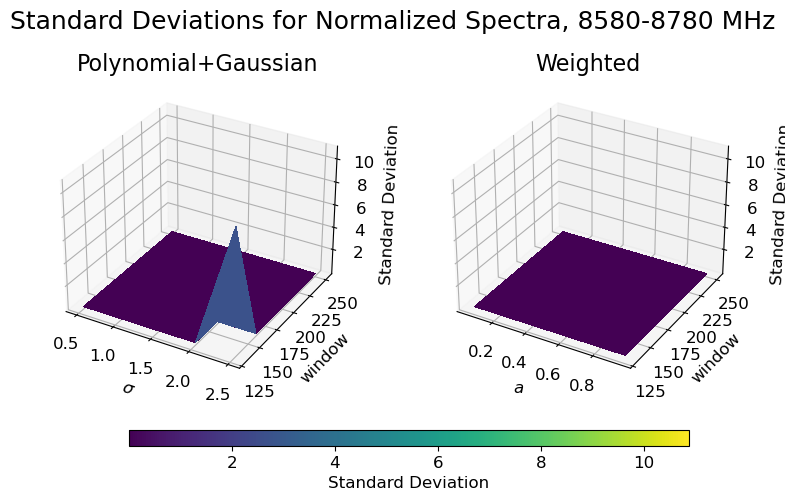

In [90]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), subplot_kw={'projection':'3d'})
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16})

elts = (
    (axs[0], pg_xx, pg_yy, pg_stds_grid, '$\sigma$', 'Polynomial+Gaussian'), 
    (axs[1], weighted_xx, weighted_yy, weighted_stds_grid, '$a$', 'Weighted')
)
min_std, max_std = min(np.min(np.array(pg_stds)), np.min(np.array(weighted_stds))), max(np.max(np.array(pg_stds)), np.max(np.array(weighted_stds)))
norm = Normalize(vmin=min_std, vmax=max_std)

for ax, xx, yy, grid, xlabel, title in elts:
    ax.set_title(title)
    surf = ax.plot_surface(xx, yy, grid, cmap=cm.viridis, norm=norm, linewidth=0, antialiased=False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('window')
    ax.set_zlabel('Standard Deviation')
    ax.set_zlim(min_std, max_std)

fig.suptitle('Standard Deviations for Normalized Spectra, 8580-8780 MHz', y=0.99)

cax = fig.add_axes([0.17,-0.10, 0.7,0.04])
cbar = fig.colorbar(surf, cax=cax, norm=norm, cmap='viridis',
             label='Standard Deviation', orientation='horizontal')

plt.tight_layout()
plt.savefig('/home/bhanselman/norm_std_comparison.png', bbox_inches='tight')

# Asymmetry SNRs

In [4]:
os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_evals')

['pg_snrs.npy', 'pg_u_snrs.npy', 'w_snrs.npy', 'uninjected', 'injected']

In [40]:
pg_snrs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_evals/pg_snrs.npy')
pg_u_snrs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_evals/pg_u_snrs.npy')
w_snrs = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_evals/w_snrs.npy')

In [52]:
list(zip(pg_snrs, itertools.product(np.arange(1.0, 2.1, 0.5), np.arange(131, 200, 30))))

[(1.8468736831571517, (1.0, 131)),
 (3.8926551901098194, (1.0, 161)),
 (4.565506681601289, (1.0, 191)),
 (1.1733986826450087, (1.5, 131)),
 (4.579647277004959, (1.5, 161)),
 (4.979107896160206, (1.5, 191)),
 (0.03660374531968638, (2.0, 131)),
 (3.551187288582012, (2.0, 161)),
 (5.272033587453138, (2.0, 191))]

In [43]:
pg_xx, pg_yy = np.meshgrid(np.arange(1.0, 2.1, 0.5), np.arange(131, 200, 30), indexing='ij')
w_xx, w_yy = np.meshgrid(np.arange(0.1, 0.31, 0.1), np.arange(131, 200, 30), indexing='ij')
pg_snrs_grid = pg_snrs.reshape(pg_xx.shape)
pg_u_snrs_grid = pg_u_snrs.reshape(pg_xx.shape)
w_snrs_grid = w_snrs.reshape(w_xx.shape)

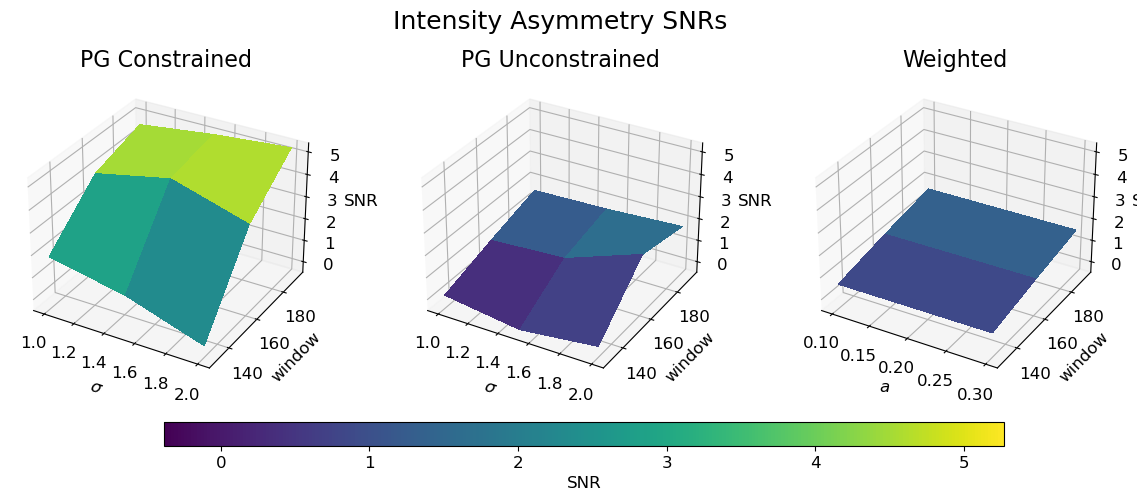

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(12,4), subplot_kw={'projection':'3d'})
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.titlesize': 18})

elts = (
    (axs[0], pg_xx, pg_yy, pg_snrs_grid, '$\sigma$', 'PG Constrained'), 
    (axs[1], pg_xx, pg_yy, pg_u_snrs_grid, '$\sigma$', 'PG Unconstrained'),
    (axs[2], w_xx, w_yy, w_snrs_grid, '$a$', 'Weighted')
)
min_snr, max_snr = min([np.min(a) for a in (pg_snrs_grid, pg_u_snrs_grid, w_snrs_grid)]), max([np.max(a) for a in (pg_snrs_grid, pg_u_snrs_grid, w_snrs_grid)])
norm = Normalize(vmin=min_snr, vmax=max_snr)

for ax, xx, yy, grid, xlabel, title in elts:
    ax.set_title(title)
    surf = ax.plot_surface(xx, yy, grid, cmap=cm.viridis, norm=norm, linewidth=0, antialiased=False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('window')
    ax.set_zlabel('SNR')
    ax.set_zlim(min_snr, max_snr)

fig.suptitle('Intensity Asymmetry SNRs', y=0.99)

cax = fig.add_axes([0.17,-0.10, 0.7,0.06])
cbar = fig.colorbar(surf, cax=cax, norm=norm, cmap='viridis',
             label='SNR', orientation='horizontal')

plt.tight_layout()
plt.savefig('/home/bhanselman/asymmetry_snr_comparison.png', bbox_inches='tight')

## PG constrained grid

In [5]:
os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_grid_new')

['0', 'snrs_0_8720.npy', '1', 'snrs_1_9520.npy', '2', 'snrs_2_10500.npy']

In [6]:
snrs_0 = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_grid_new/snrs_0_8720.npy')
snrs_1 = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_grid_new/snrs_1_9520.npy')
snrs_2 = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_grid_new/snrs_2_10500.npy')

In [7]:
list(zip(snrs_0, itertools.product(np.arange(1.0, 2.1, 0.5), np.arange(161, 261, 30))))

[(4.211614338503766, (1.0, 161)),
 (4.699158162561019, (1.0, 191)),
 (4.5297754423628005, (1.0, 221)),
 (4.746303444400199, (1.0, 251)),
 (4.841916399576392, (1.5, 161)),
 (5.130669874377305, (1.5, 191)),
 (4.784869981116197, (1.5, 221)),
 (5.0547285130442114, (1.5, 251)),
 (3.678146137652145, (2.0, 161)),
 (5.2236101801251795, (2.0, 191)),
 (4.810199376128888, (2.0, 221)),
 (4.541076801827939, (2.0, 251))]

In [8]:
xx, yy = np.meshgrid(np.arange(1.0, 2.1, 0.5), np.arange(161, 261, 30), indexing='ij')
snrs_0_grid = snrs_0.reshape(xx.shape)
snrs_1_grid = snrs_1.reshape(xx.shape)
snrs_2_grid = snrs_2.reshape(xx.shape)

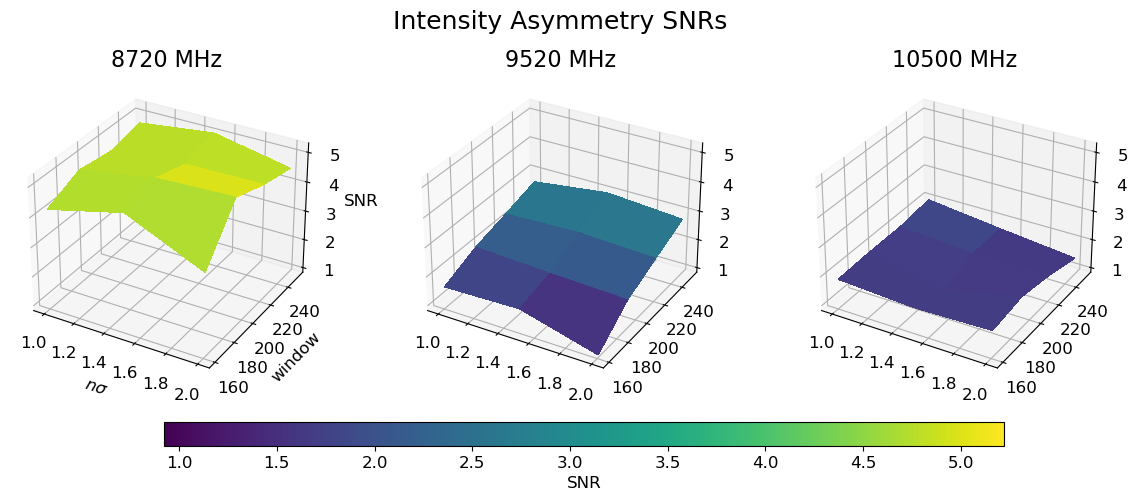

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12,4), subplot_kw={'projection':'3d'})
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.titlesize': 18})

elts = (
    (axs[0], snrs_0_grid, '8720 MHz'), 
    (axs[1], snrs_1_grid, '9520 MHz'),
    (axs[2], snrs_2_grid, '10500 MHz')
)
min_snr, max_snr = min([np.min(a) for a in (snrs_0_grid, snrs_1_grid, snrs_2_grid)]), max([np.max(a) for a in (snrs_0_grid, snrs_1_grid, snrs_2_grid)])
norm = Normalize(vmin=min_snr, vmax=max_snr)

for ax, grid, title in elts:
    ax.set_title(title)
    surf = ax.plot_surface(xx, yy, grid, cmap=cm.viridis, norm=norm, linewidth=0, antialiased=False)
    if ax == axs[0]:
        ax.set_xlabel('$n\sigma$')
        ax.set_ylabel('window')
        ax.set_zlabel('SNR')
    ax.set_zlim(min_snr, max_snr)

fig.suptitle('Intensity Asymmetry SNRs', y=0.99)

cax = fig.add_axes([0.17,-0.10, 0.7,0.06])
cbar = fig.colorbar(surf, cax=cax, norm=norm, cmap='viridis',
             label='SNR', orientation='horizontal')

plt.tight_layout()
plt.savefig('/home/bhanselman/grid_asymmetry_snr_new.png', bbox_inches='tight')

## Whyyyyyy

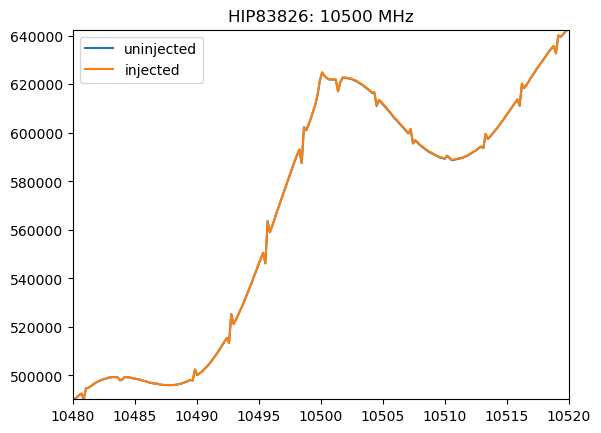

In [7]:
uninjected_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/2/preprocessed/'
injected_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_bayes_new/2/injected/'
name = os.listdir(injected_dir)[300]
uninj_path = os.path.join(uninjected_dir, name)
inj_path = os.path.join(injected_dir, name)
uninj = np.load(uninj_path)
inj = np.load(inj_path)
plt.plot(*uninj, label='uninjected')
plt.plot(*inj, label='injected')
xlim = (10480, 10520)
plt.xlim(*xlim)
window = inj[1][(inj[0] < xlim[1]) & (inj[0] > xlim[0])]
plt.ylim(np.min(window), np.max(window))
plt.title(f'{name[:-4]}: 10500 MHz')
plt.legend()

## One bank, multiple signals results

In [2]:
xx, yy = np.meshgrid(np.arange(1.0, 2.1, 0.5), np.arange(0.015, 0.040, 0.005), indexing='ij')
snr_grids = []
snr_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_grid_bank_2/'
files = [file for file in os.listdir(snr_dir) if file.endswith('.npy')]
for file in files:
    snrs = np.load(os.path.join(snr_dir, file))
    snrs_norm = snrs / np.max(snrs)
    snr_grid = snrs_norm.reshape(xx.shape)
    snr_grids.append(snr_grid)
snr_grids_mean = np.mean(snr_grids, axis=0)
snr_grids_mean

array([[0.40919157, 0.42890918, 0.47729033, 0.53315512, 0.7175368 ],
       [0.40844664, 0.41093677, 0.46595349, 0.55026753, 0.78428807],
       [0.18047851, 0.3640835 , 0.39223891, 0.52489112, 0.83194307]])

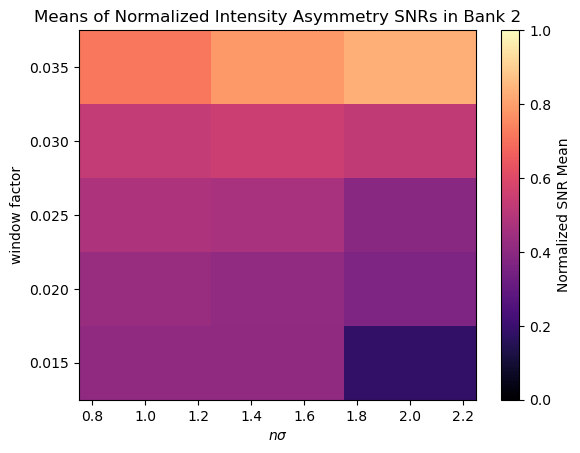

In [3]:
norm = Normalize(vmin=0, vmax=1)
plt.pcolormesh(xx, yy, snr_grids_mean, cmap='magma', norm=norm)
plt.colorbar(label='Normalized SNR Mean')
plt.xlabel('$n\sigma$')
plt.ylabel('window factor')
plt.title('Means of Normalized Intensity Asymmetry SNRs in Bank 2')
plt.savefig('/home/bhanselman/images/snr_norm_grid_avg_bank_2.png', dpi=500)

### Window factor dependence on frequency?!??!

[0.015 0.02  0.025 0.03  0.035 0.015 0.02  0.025 0.03  0.035 0.015 0.02
 0.025 0.03  0.035]


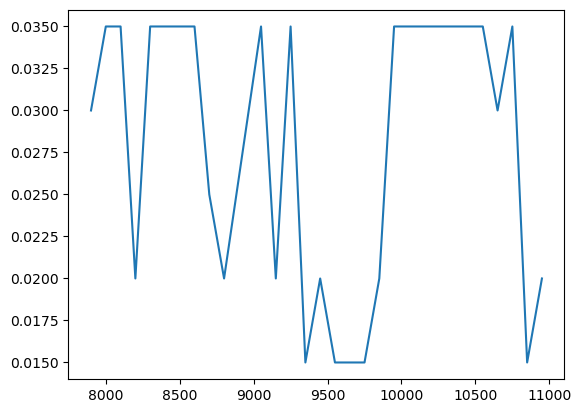

In [8]:
banks = list(range(3))
xs = []
ys = []
yy_flattened = yy.flatten()
print(yy_flattened)
for bank in banks:
    snr_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_grid_bank_{bank}/'
    files = [file for file in os.listdir(snr_dir) if file.endswith('.npy')]
    for file in files:
        snrs = np.load(os.path.join(snr_dir, file))
        snrs_argmax = np.argmax(snrs)
        window_factor = yy_flattened[snrs_argmax]
        freq = int(file.split('_')[1].split('.')[0])
        xs.append(freq)
        ys.append(window_factor)

plt.plot(xs, ys)

# Investigating the blips...

In [ ]:
spikes = []
weird_spikes = []
for i, loc in tqdm(enumerate(spectra)):
    spectrum = Spectrum(combed_dir + loc)
    maxth = spectrum.freq[np.argmax(spectrum.power)]
    if round(maxth) != 10700: weird_spikes.append(i)
    spikes.append(maxth)
plt.hist(spikes, bins=100)

In [ ]:
weirdos = [spectra[i] for i in weird_spikes]
for loc in weirdos:
    spectrum = Spectrum(combed_dir + loc)
    spectrum.plot()

# Despiking

In [2]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/'

def clean(loc, nsigma=7, in_dir=None, out_dir=None):
    spectrum = Spectrum(os.path.join(in_dir, loc), interpret=False)
    spectrum.sigma_filter()
    
    cleaned = np.array([spectrum.freq, spectrum.power])
    np.save(os.path.join(out_dir, loc), cleaned)

banks = ['0', '1', '2', '3']

with Pool(maxtasksperchild=10) as p:
    for bank in banks:
        print(bank)
        in_dir = os.path.join(data_dir, bank, 'preprocessed')
        out_dir = os.path.join(data_dir, bank, 'preprocessed_despiked')
        os.makedirs(out_dir, exist_ok=True)
        
        spectra_to_clean = os.listdir(in_dir)
        clean_partial = partial(clean, in_dir=in_dir, out_dir=out_dir)
        
        result = list(tqdm(p.imap_unordered(clean_partial, spectra_to_clean), total=len(spectra_to_clean)))

0


100%|█████████████████████████████████████████████████████████████████████| 4918/4918 [20:20<00:00,  4.03it/s]

1



100%|█████████████████████████████████████████████████████████████████████| 4837/4837 [22:51<00:00,  3.53it/s]


2


100%|█████████████████████████████████████████████████████████████████████| 4832/4832 [22:43<00:00,  3.54it/s]


3


100%|█████████████████████████████████████████████████████████████████████| 1420/1420 [06:41<00:00,  3.54it/s]


# Throwing out spectra with discontinuities

In [31]:
from tqdm.notebook import tqdm

data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/'
save_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/'
os.makedirs(save_dir, exist_ok=True)

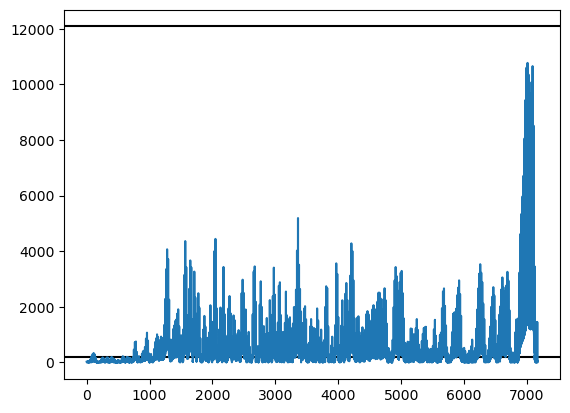

In [35]:
path = os.path.join(data_dir, '0/preprocessed_despiked')
name = random.choice(os.listdir(path))
spec = np.load(os.path.join(path, name))
grad = abs(np.diff(spec[1]))
med, std = np.median(grad), np.std(grad)
plt.axhline(med, c='k')
plt.axhline(med + 20 * std, c='k')
plt.plot(grad)

(7900.0, 8100.0)

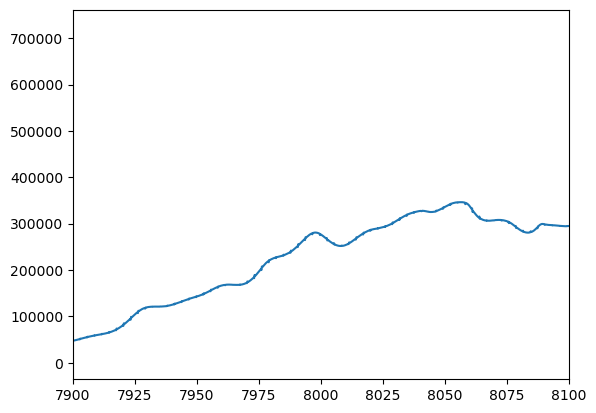

In [5]:
plt.plot(*spec)
plt.xlim(7900, 8100)

In [37]:
banks = ['0', '1', '2', '3']

bad_names = {}

for bank in banks:
    bad_names[bank] = []
    
    tail = f'{bank}/preprocessed_despiked'
    tail2 = f'preprocessed/{bank}'
    ddir = os.path.join(data_dir, tail)
    sdir = os.path.join(save_dir, tail2)
    os.makedirs(sdir, exist_ok=True)
    
    for file in tqdm(os.listdir(ddir)):
        spec = np.load(os.path.join(ddir, file))
        grad = abs(np.diff(spec[1]))
        med, std = np.median(grad), np.std(grad)
        if (max(grad) - med < 40 * std) and (spec[0][0] > 7600):
            np.save(os.path.join(sdir, file), spec)
        else:
            bad_names[bank].append(file)
    
    print(len(os.listdir(sdir)))
print(bad_names)

  0%|          | 0/4918 [00:00<?, ?it/s]

4775


  0%|          | 0/4837 [00:00<?, ?it/s]

4653


  0%|          | 0/4832 [00:00<?, ?it/s]

4511


  0%|          | 0/1420 [00:00<?, ?it/s]

1409
{'0': ['HIP100046.npy', 'HIP100058.npy', 'HIP100387.npy', 'HIP101646.npy', 'HIP100816.npy', 'HIP102193.npy', 'HIP103001.npy', 'HIP103841.npy', 'HIP103984.npy', 'HIP104355.npy', 'HIP104547.npy', 'HIP10559.npy', 'HIP106066.npy', 'HIP106307.npy', 'HIP106852.npy', 'HIP111303.npy', 'HIP111356.npy', 'HIP112068.npy', 'HIP112126.npy', 'HIP112142.npy', 'HIP112173.npy', 'HIP112187.npy', 'HIP112191.npy', 'HIP112232.npy', 'HIP112328.npy', 'HIP112332.npy', 'HIP112354.npy', 'HIP112360.npy', 'HIP112416.npy', 'HIP112422.npy', 'HIP112447.npy', 'HIP112453.npy', 'HIP112482.npy', 'HIP112870.npy', 'HIP112909.npy', 'HIP112918.npy', 'HIP112935.npy', 'HIP113006.npy', 'HIP115279.npy', 'HIP115359.npy', 'HIP115551.npy', 'HIP115817.npy', 'HIP11635.npy', 'HIP116359.npy', 'HIP116756.npy', 'HIP116971.npy', 'HIP117261.npy', 'HIP117476.npy', 'HIP14145.npy', 'HIP1444.npy', 'HIP14658.npy', 'HIP17231.npy', 'HIP18455.npy', 'HIP18655.npy', 'HIP19016.npy', 'HIP19053.npy', 'HIP19106.npy', 'HIP21040.npy', 'HIP21342.npy',

(0.0, 10000000000.0)

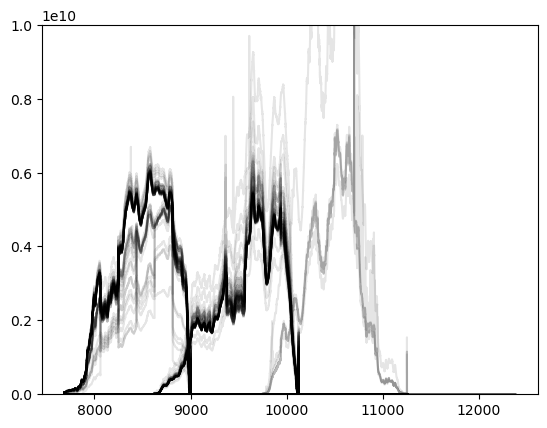

In [195]:
for bank in banks:
    for file in bad_names[bank]:
        spec = np.load(os.path.join(data_dir, f'{bank}/preprocessed', file))
        plt.plot(*spec, c='k', alpha=0.1)
        
plt.ylim(0, 1e10)

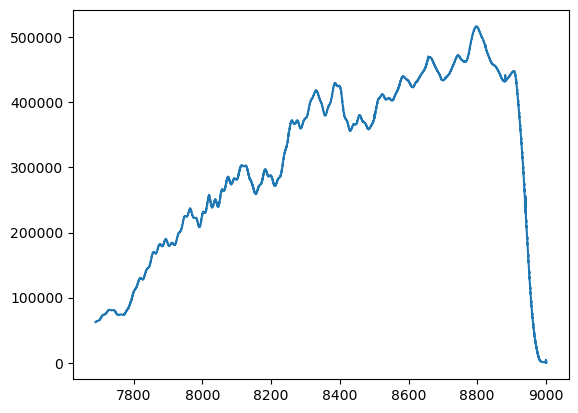

In [303]:
random_name = random.choice(bad_names['2'])
spec = np.load(os.path.join(data_dir, '0/preprocessed_despiked', random_name))
plt.plot(*spec)

# What the fuck

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 4.298e+03]),
 array([567. , 567.3, 567.6, 567.9, 568.2, 568.5, 568.8, 569.1, 569.4,
        569.7, 570. ]),
 <BarContainer object of 10 artists>)

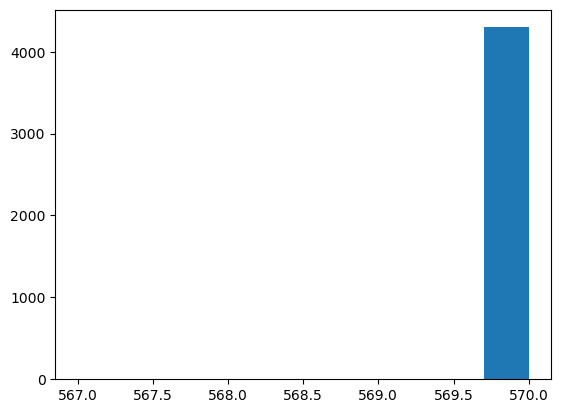

In [11]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8630_8730_mhz/ann/8630/1e-25/normalized_template/'
shapes = [np.load(os.path.join(data_dir, name)).shape[1] for name in os.listdir(data_dir)]
plt.hist(shapes)

(array([2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

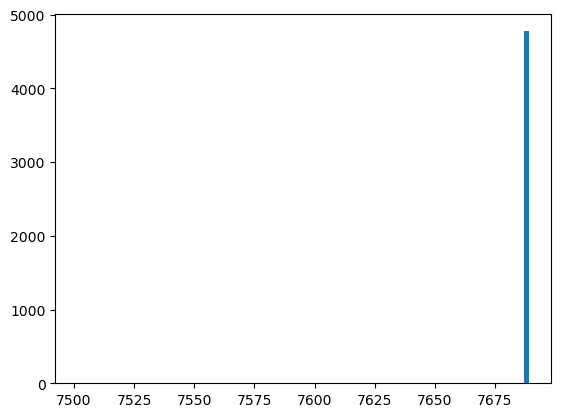

In [30]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8630_8730_mhz/ann/8630/1e-25/template/'
start_freqs = [np.load(os.path.join(data_dir, name))[0][0] for name in os.listdir(data_dir)]
plt.hist(start_freqs, bins=100)

In [16]:
from scipy.stats import mode
mode(shapes).mode

array([570])

In [17]:
for name in os.listdir(data_dir):
    if np.load(os.path.join(data_dir, name)).shape[1] != mode(shapes).mode:
        print(name)

HIP50856.npy


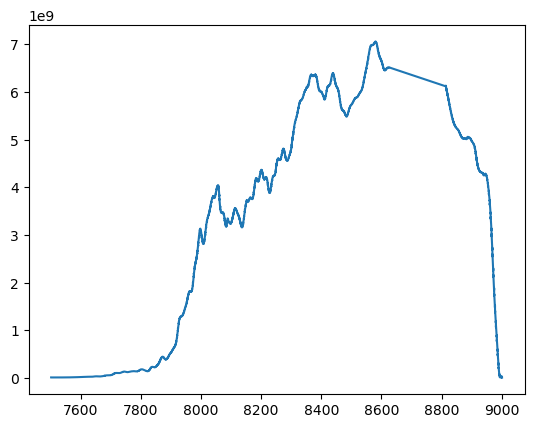

In [27]:
d_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8630_8730_mhz/ann/8630/1e-25/injected/'
plt.plot(*np.load(os.path.join(d_dir, 'HIP50856.npy'))) #random.choice(os.listdir(data_dir))

In [38]:
info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/all_xband_info.csv'
info = pd.read_csv(info_dir)

def build_asymmetry(data_dir, angle, lower, upper):
    spectra = os.listdir(data_dir)
    inner = info[info[angle] < lower]
    outer = info[info[angle] > upper]
    inner_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner['source'].tolist()])
    outer_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer['source'].tolist()])
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    return xs, asymmetry

dir_name = f'analyses/8630_8730_mhz/decay/8630/3e-29'
uninj_save_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/{dir_name}/normalized_uninjected/'
inj_save_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/{dir_name}/normalized_injected/'
temp_save_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/{dir_name}/normalized_template/'

xs, uninj_dopp = build_asymmetry(uninj_save_dir, 'theta', 65, 65)
xs, inj_dopp = build_asymmetry(inj_save_dir, 'theta', 65, 65)
xs, temp_dopp = build_asymmetry(temp_save_dir, 'theta', 65, 65)

xs, uninj_int = build_asymmetry(uninj_save_dir, 'phi', 70, 115)
xs, inj_int = build_asymmetry(inj_save_dir, 'phi', 70, 115)
xs, temp_int = build_asymmetry(temp_save_dir, 'phi', 70, 115)

In [51]:
name = random.choice(os.listdir(temp_save_dir))

In [56]:
inner = info[info['phi'] < 70]
outer = info[info['phi'] > 115]
for name in os.listdir(temp_save_dir):
    spec = np.load(os.path.join(temp_save_dir, name))
    if name[:-4] in inner['source'].tolist():
        color = 'blue'
        plt.plot(*spec, c=color, alpha=0.1)
    elif name[:-4] in outer['source'].tolist():
        color = 'red'
    else:
        color = 'black'

In [63]:
info[info['theta'] > 65]

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP62637,AGBT23B_999_14,60291_31980,192.5380,19.8676,300.540925,82.733377,96.254146,86.314790,1.660433e+08,1.202716e+15,3.237142e+08,1.860099e+15,1.442647e+08,9.590752e+14,3.834180e+07,7.402785e+13
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
4,HIP53862,AGBT20A_999_44,59023_07533,165.2817,-5.7016,259.734245,47.703048,131.467876,96.888255,1.479999e+08,9.745009e+14,3.075883e+08,1.679683e+15,1.285353e+08,7.858121e+14,3.370077e+07,5.890246e+13
5,HIP52857,AGBT20A_999_44,59023_05612,162.0880,-3.2380,253.765522,47.537077,130.405520,100.879297,1.423257e+08,9.086361e+14,3.020567e+08,1.620386e+15,1.235275e+08,7.347209e+14,3.225975e+07,5.461330e+13
6,HIP58084,AGBT20A_999_44,59023_08409,178.6864,-14.0182,282.698821,46.614305,132.075071,81.315123,1.764020e+08,1.347178e+15,3.320596e+08,1.957965e+15,1.531393e+08,1.065647e+15,4.104547e+07,8.379990e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4952,HIP23282,AGBT20A_999_50,59033_49276,75.1433,36.6261,168.309624,-3.448953,78.331096,167.818268,1.000745e+08,4.999762e+14,2.523721e+08,1.144418e+15,8.566477e+07,4.081957e+14,2.182834e+07,2.887520e+13
4953,HIP19903,AGBT20A_999_50,59033_73785,64.0669,34.8577,163.650538,-11.357061,73.979383,160.181860,1.014395e+08,5.110589e+14,2.542487e+08,1.160608e+15,8.689594e+07,4.172304e+14,2.215657e+07,2.955115e+13
4954,HIP24356,AGBT20A_999_50,59033_50565,78.3883,35.7140,170.613162,-1.900165,80.618370,170.424459,9.976103e+07,4.974495e+14,2.519381e+08,1.140693e+15,8.538199e+07,4.061349e+14,2.175304e+07,2.872128e+13
4955,HIP24587,AGBT20A_999_50,59033_49921,79.1152,36.0731,170.664507,-1.212358,80.666616,170.586807,9.974402e+07,4.973126e+14,2.519145e+08,1.140491e+15,8.536665e+07,4.060232e+14,2.174896e+07,2.871295e+13


In [60]:
len(os.listdir(temp_save_dir))

4297